# Unified Multi-Disease Retinal Disease Detection Using Deep Learning and Explainable AI

Complete Colab-ready pipeline: ODIR-5K + RFMiD, EfficientNetV2-S, GradCAM, Cross-Dataset
Evaluation, Temperature Scaling Calibration, and Error Analysis.

Run cells **in order, top to bottom**. Each module builds files under `/content/project/`
that later modules import.

## Module 1 — Project Structure

In [1]:
# CELL 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_ROOT = "/content/drive/MyDrive/retinal_disease_project"
os.makedirs(DRIVE_ROOT, exist_ok=True)
print("Drive mounted. Project root:", DRIVE_ROOT)

Mounted at /content/drive
Drive mounted. Project root: /content/drive/MyDrive/retinal_disease_project


In [10]:
# CELL 2: Create modular project structure
import os

PROJECT_ROOT = "/content/project"
DRIVE_ROOT = "/content/drive/MyDrive/retinal_disease_project"

FOLDERS = [
    "configs", "datasets", "preprocessing", "augmentation", "models",
    "losses", "training", "evaluation", "utils", "gradcam", "weights",
    "outputs/curves", "outputs/confusion_matrix", "outputs/gradcam_images",
    "outputs/predictions", "notebooks", "prediction",
]

def create_structure(root):
    for folder in FOLDERS:
        path = os.path.join(root, folder)
        os.makedirs(path, exist_ok=True)
        if folder in ["datasets", "preprocessing", "augmentation", "models",
                       "losses", "training", "evaluation", "utils", "gradcam", "prediction"]:
            open(os.path.join(path, "__init__.py"), "a").close()

create_structure(PROJECT_ROOT)
os.makedirs(os.path.join(DRIVE_ROOT, "weights"), exist_ok=True)
os.makedirs(os.path.join(DRIVE_ROOT, "outputs"), exist_ok=True)

print("Project structure created at:", PROJECT_ROOT)

Project structure created at: /content/project


In [11]:
# CELL 3: configs/config.py
config_code = """
class Config:
    PROJECT_ROOT = "/content/project"
    DRIVE_ROOT = "/content/drive/MyDrive/retinal_disease_project"
    DATA_DIR = "/content/data"
    WEIGHTS_DIR = DRIVE_ROOT + "/weights"
    OUTPUTS_DIR = DRIVE_ROOT + "/outputs"

    DATASET = "ODIR5K"
    IMG_SIZE = 224
    NUM_CLASSES = 8

    BACKBONE = "efficientnetv2_s"
    PRETRAINED = True

    LOSS_TYPE = "bce"
    USE_CLASS_WEIGHTS = True
    FOCAL_ALPHA = 0.25
    FOCAL_GAMMA = 2.0

    BATCH_SIZE = 8
    NUM_WORKERS = 2
    PIN_MEMORY = True
    PERSISTENT_WORKERS = False
    EPOCHS = 30
    LR = 1e-4
    WEIGHT_DECAY = 1e-5
    GRAD_CLIP_NORM = 1.0
    GRAD_ACCUM_STEPS = 2
    USE_AMP = True
    EARLY_STOPPING_PATIENCE = 5
    LR_SCHEDULER = "cosine"

    SEED = 42
    GRADCAM_TARGET_LAYER = "auto"

CFG = Config()
"""

config_path = os.path.join(PROJECT_ROOT, "configs", "config.py")
with open(config_path, "w") as f:
    f.write(config_code)

print("Config file written to:", config_path)

Config file written to: /content/project/configs/config.py


In [12]:
# CELL 4: TEST — verify folders exist and config imports correctly
import sys
sys.path.append(PROJECT_ROOT)

missing = [f for f in FOLDERS if not os.path.isdir(os.path.join(PROJECT_ROOT, f))]
assert len(missing) == 0, f"Missing folders: {missing}"
print("All folders created successfully.")

from configs.config import CFG
assert CFG.IMG_SIZE == 224
assert CFG.BATCH_SIZE == 8
print("Config loaded successfully.")
print(f"   Backbone: {CFG.BACKBONE}")
print(f"   Dataset: {CFG.DATASET}")

import torch
if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected — go to Runtime > Change runtime type > GPU")

All folders created successfully.
Config loaded successfully.
   Backbone: efficientnetv2_s
   Dataset: ODIR5K
GPU detected: Tesla T4


## Module 2 — Dataset Loader (ODIR-5K)

In [13]:
# CELL 1: Download ODIR-5K dataset using kagglehub (no kaggle.json needed)
!pip install -q kagglehub

import kagglehub
import shutil
import os

DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

download_path = kagglehub.dataset_download(
    "andrewmvd/ocular-disease-recognition-odir5k"
)

print("Downloaded to cache:", download_path)

destination = os.path.join(DATA_DIR, "ocular-disease-recognition-odir5k")

if os.path.exists(destination):
    shutil.rmtree(destination)

shutil.copytree(download_path, destination)

print("Dataset copied to:", destination)

100%|██████████| 1.62G/1.62G [01:34<00:00, 18.4MB/s]

Extracting files...


Downloaded to cache: /root/.cache/kagglehub/datasets/andrewmvd/ocular-disease-recognition-odir5k/versions/2
Dataset copied to: /content/data/ocular-disease-recognition-odir5k


In [14]:
# CELL 2: Locate image folder and label file
import glob
import pandas as pd

candidate_labels = glob.glob(f"{DATA_DIR}/**/*.xlsx", recursive=True) + \
                    glob.glob(f"{DATA_DIR}/**/*full_df.csv", recursive=True)
candidate_img_dirs = [d for d in glob.glob(f"{DATA_DIR}/**/", recursive=True)
                       if "image" in d.lower()]

print("Found label files:", candidate_labels)
print("Found candidate image dirs:", candidate_img_dirs[:5])

LABEL_FILE = candidate_labels[0] if candidate_labels else None
IMAGE_DIR = candidate_img_dirs[0] if candidate_img_dirs else None

assert LABEL_FILE is not None, "Label file not found — set LABEL_FILE manually."
assert IMAGE_DIR is not None, "Image directory not found — set IMAGE_DIR manually."

if LABEL_FILE.endswith(".xlsx"):
    raw_df = pd.read_excel(LABEL_FILE)
else:
    raw_df = pd.read_csv(LABEL_FILE)

print(f"Label file: {LABEL_FILE}")
print(f"Image dir: {IMAGE_DIR}")
print(f"Raw label sheet shape: {raw_df.shape}")
raw_df.head(3)

Found label files: ['/content/data/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/data.xlsx', '/content/data/ocular-disease-recognition-odir5k/full_df.csv']
Found candidate image dirs: ['/content/data/ocular-disease-recognition-odir5k/preprocessed_images/', '/content/data/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/', '/content/data/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Testing Images/']
Label file: /content/data/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/data.xlsx
Image dir: /content/data/ocular-disease-recognition-odir5k/preprocessed_images/
Raw label sheet shape: (3500, 15)


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1


In [15]:
import sys
import os
import importlib.util

# Ensure the project root is in path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# CELL 3: datasets/build_odir_labels.py — flatten patient rows into per-image rows
build_labels_code = """
import pandas as pd
import os

DISEASE_COLS = ["N", "D", "G", "C", "A", "H", "M", "O"]

def build_flat_label_csv(raw_df, image_dir, save_path):
    rows = []
    missing_files = 0

    for _, r in raw_df.iterrows():
        labels = [int(r[c]) for c in DISEASE_COLS]

        for side_col in ["Left-Fundus", "Right-Fundus"]:
            fname = r.get(side_col, None)
            if pd.isna(fname):
                continue
            full_path = os.path.join(image_dir, fname)
            if not os.path.exists(full_path):
                missing_files += 1
                continue
            rows.append([fname] + labels)

    flat_df = pd.DataFrame(rows, columns=["filename"] + DISEASE_COLS)
    flat_df.to_csv(save_path, index=False)

    print(f"Built flat label CSV: {len(flat_df)} images ({missing_files} missing files skipped)")
    return flat_df
"""

# 1. Create directory and __init__.py
module_dir = os.path.join(PROJECT_ROOT, "datasets")
os.makedirs(module_dir, exist_ok=True)
with open(os.path.join(module_dir, "__init__.py"), "w") as f:
    f.write("")

# 2. Write the module file
module_file_path = os.path.join(module_dir, "build_odir_labels.py")
with open(module_file_path, "w") as f:
    f.write(build_labels_code)

# 3. Use importlib to load directly from path to bypass cache issues
spec = importlib.util.spec_from_file_location("build_odir_labels", module_file_path)
build_odir_labels = importlib.util.module_from_spec(spec)
sys.modules["datasets.build_odir_labels"] = build_odir_labels
spec.loader.exec_module(build_odir_labels)

from datasets.build_odir_labels import build_flat_label_csv

# 4. Run the function
flat_label_path = os.path.join(PROJECT_ROOT, "datasets", "odir_flat_labels.csv")
flat_df = build_flat_label_csv(raw_df, IMAGE_DIR, flat_label_path)
print(flat_df.head())

Built flat label CSV: 6392 images (608 missing files skipped)
      filename  N  D  G  C  A  H  M  O
0   0_left.jpg  0  0  0  1  0  0  0  0
1  0_right.jpg  0  0  0  1  0  0  0  0
2   1_left.jpg  1  0  0  0  0  0  0  0
3  1_right.jpg  1  0  0  0  0  0  0  0
4  2_right.jpg  0  1  0  0  0  0  0  1


In [16]:
# CELL 4: datasets/odir_dataset.py — PyTorch Dataset for flat label CSV
odir_dataset_code = """
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

DISEASE_COLS = ["N", "D", "G", "C", "A", "H", "M", "O"]

class ODIRDataset(Dataset):
    def __init__(self, df, image_dir, img_size=224, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.img_size = img_size
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _load_image(self, filename):
        path = os.path.join(self.image_dir, filename)
        img = cv2.imread(path)
        if img is None:
            print(f"Could not read image: {path} — using black placeholder")
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size, self.img_size))
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = self._load_image(row["filename"])
        labels = row[DISEASE_COLS].values.astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image)
            image = augmented["image"]
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0

        return image, torch.from_numpy(labels)
"""

with open(os.path.join(PROJECT_ROOT, "datasets", "odir_dataset.py"), "w") as f:
    f.write(odir_dataset_code)

print("Written: datasets/odir_dataset.py")

Written: datasets/odir_dataset.py


In [17]:
# CELL 5: Split flat_df into train/val/test
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(flat_df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_df.to_csv(os.path.join(PROJECT_ROOT, "datasets", "train_split.csv"), index=False)
val_df.to_csv(os.path.join(PROJECT_ROOT, "datasets", "val_split.csv"), index=False)
test_df.to_csv(os.path.join(PROJECT_ROOT, "datasets", "test_split.csv"), index=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 5113 | Val: 639 | Test: 640


In [18]:
# CELL 6: TEST — load a batch and verify shapes/types
import sys
import os
import importlib.util
from torch.utils.data import DataLoader
from configs.config import CFG

# 1. Use importlib to load directly from path to bypass cache issues
module_path = os.path.join(PROJECT_ROOT, "datasets", "odir_dataset.py")
spec = importlib.util.spec_from_file_location("odir_dataset", module_path)
odir_dataset_mod = importlib.util.module_from_spec(spec)
sys.modules["datasets.odir_dataset"] = odir_dataset_mod
spec.loader.exec_module(odir_dataset_mod)

from datasets.odir_dataset import ODIRDataset

train_dataset = ODIRDataset(train_df, IMAGE_DIR, img_size=CFG.IMG_SIZE)

img, label = train_dataset[0]
assert img.shape == (3, CFG.IMG_SIZE, CFG.IMG_SIZE)
assert label.shape == (8,)
print("Single sample shapes correct.")
print(f"   Image shape: {img.shape}, dtype: {img.dtype}")
print(f"   Label: {label}")

loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=CFG.PIN_MEMORY,
    persistent_workers=CFG.PERSISTENT_WORKERS,
)

batch_imgs, batch_labels = next(iter(loader))
assert batch_imgs.shape == (CFG.BATCH_SIZE, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
assert batch_labels.shape == (CFG.BATCH_SIZE, 8)
print("Batch shapes correct.")

DISEASE_COLS = ["N", "D", "G", "C", "A", "H", "M", "O"]
label_counts = train_df[DISEASE_COLS].sum()
print("Per-class positive counts in train split:")
print(label_counts)

Single sample shapes correct.
   Image shape: torch.Size([3, 224, 224]), dtype: torch.float32
   Label: tensor([0., 0., 1., 0., 0., 0., 0., 0.])
Batch shapes correct.
Per-class positive counts in train split:
N    1685
D    1701
G     322
C     315
A     247
H     172
M     256
O    1258
dtype: int64


## Module 3 — Label Mapping (Unified Taxonomy)

In [19]:
# CELL 1: preprocessing/label_mapping.py — unified disease taxonomy
label_mapping_code = """
UNIFIED_CLASSES = ["N", "D", "G", "C", "A", "H", "M", "O"]

RFMID_TO_UNIFIED = {
    "DR": "D",
    "ARMD": "A",
    "MYA": "M",
    "HTN": "H",
    "ODC": "G",
    "CATARACT": "C",
    "TSLN": "O", "MH": "O", "DN": "O", "BRVO": "O", "CRVO": "O",
    "ODP": "O", "ODPM": "O", "TV": "O", "CRS": "O", "EDN": "O",
    "RPEC": "O", "MHL": "O", "RS": "O", "CRAO": "O", "TD": "O",
    "CME": "O", "PTCR": "O", "CF": "O", "VH": "O", "MCA": "O",
    "VS": "O", "BRAO": "O", "PLQ": "O", "HPED": "O", "CL": "O",
    "ST": "O", "AION": "O", "PT": "O", "RT": "O", "RS_": "O",
    "CSR": "O", "PSC": "O", "CWS": "O", "PAN": "O",
}

def map_rfmid_row_to_unified(row, rfmid_columns):
    import numpy as np
    vec = np.zeros(len(UNIFIED_CLASSES), dtype=np.float32)

    if "Disease_Risk" in rfmid_columns and int(row["Disease_Risk"]) == 0:
        vec[UNIFIED_CLASSES.index("N")] = 1.0
        return vec

    matched_any = False
    for col in rfmid_columns:
        if col in ("ID", "Disease_Risk"):
            continue
        if col in RFMID_TO_UNIFIED and int(row.get(col, 0)) == 1:
            unified_letter = RFMID_TO_UNIFIED[col]
            vec[UNIFIED_CLASSES.index(unified_letter)] = 1.0
            matched_any = True

    if not matched_any and "Disease_Risk" in rfmid_columns and int(row["Disease_Risk"]) == 1:
        vec[UNIFIED_CLASSES.index("O")] = 1.0

    return vec
"""

with open(os.path.join(PROJECT_ROOT, "preprocessing", "label_mapping.py"), "w") as f:
    f.write(label_mapping_code)

print("Written: preprocessing/label_mapping.py")

Written: preprocessing/label_mapping.py


In [20]:
# CELL 2: preprocessing/odir_to_unified.py — trivial passthrough
odir_to_unified_code = """
import numpy as np
from preprocessing.label_mapping import UNIFIED_CLASSES

def map_odir_row_to_unified(row):
    vec = np.array([float(row[c]) for c in UNIFIED_CLASSES], dtype=np.float32)
    return vec
"""

with open(os.path.join(PROJECT_ROOT, "preprocessing", "odir_to_unified.py"), "w") as f:
    f.write(odir_to_unified_code)

print("Written: preprocessing/odir_to_unified.py")

Written: preprocessing/odir_to_unified.py


In [21]:
# CELL 3: TEST — verify mapping correctness on synthetic + real data
import sys, importlib
sys.path.append(PROJECT_ROOT)

import preprocessing.label_mapping as lm
import preprocessing.odir_to_unified as otu
importlib.reload(lm)
importlib.reload(otu)

from preprocessing.label_mapping import UNIFIED_CLASSES, map_rfmid_row_to_unified
from preprocessing.odir_to_unified import map_odir_row_to_unified

assert UNIFIED_CLASSES == ["N", "D", "G", "C", "A", "H", "M", "O"]
print("Unified taxonomy order correct:", UNIFIED_CLASSES)

rfmid_cols = ["ID", "Disease_Risk", "DR", "ARMD", "MYA", "HTN", "ODC", "TSLN"]
row_normal = {"ID": 1, "Disease_Risk": 0, "DR": 0, "ARMD": 0, "MYA": 0, "HTN": 0, "ODC": 0, "TSLN": 0}
vec = map_rfmid_row_to_unified(row_normal, rfmid_cols)
assert vec.tolist() == [1, 0, 0, 0, 0, 0, 0, 0]
print("RFMiD normal row -> [N] correct:", vec)

row_dr = {"ID": 2, "Disease_Risk": 1, "DR": 1, "ARMD": 0, "MYA": 0, "HTN": 0, "ODC": 0, "TSLN": 0}
vec = map_rfmid_row_to_unified(row_dr, rfmid_cols)
assert vec[UNIFIED_CLASSES.index("D")] == 1.0
print("RFMiD DR row -> [D] correct:", vec)

row_multi = {"ID": 3, "Disease_Risk": 1, "DR": 0, "ARMD": 1, "MYA": 1, "HTN": 0, "ODC": 0, "TSLN": 0}
vec = map_rfmid_row_to_unified(row_multi, rfmid_cols)
assert vec[UNIFIED_CLASSES.index("A")] == 1.0 and vec[UNIFIED_CLASSES.index("M")] == 1.0
print("RFMiD multi-label row -> [A, M] correct:", vec)

row_other = {"ID": 4, "Disease_Risk": 1, "DR": 0, "ARMD": 0, "MYA": 0, "HTN": 0, "ODC": 0, "TSLN": 1}
vec = map_rfmid_row_to_unified(row_other, rfmid_cols)
assert vec[UNIFIED_CLASSES.index("O")] == 1.0
print("RFMiD other condition -> [O] correct:", vec)

sample_odir_row = flat_df.iloc[0]
odir_vec = map_odir_row_to_unified(sample_odir_row)
expected = sample_odir_row[UNIFIED_CLASSES].values.astype(float)
assert (odir_vec == expected).all()
print("ODIR passthrough mapping correct:", odir_vec)

print("All label mapping tests passed.")

Unified taxonomy order correct: ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
RFMiD normal row -> [N] correct: [1. 0. 0. 0. 0. 0. 0. 0.]
RFMiD DR row -> [D] correct: [0. 1. 0. 0. 0. 0. 0. 0.]
RFMiD multi-label row -> [A, M] correct: [0. 0. 0. 0. 1. 0. 1. 0.]
RFMiD other condition -> [O] correct: [0. 0. 0. 0. 0. 0. 0. 1.]
ODIR passthrough mapping correct: [0. 0. 0. 1. 0. 0. 0. 0.]
All label mapping tests passed.


## Module 4 — Preprocessing

In [22]:
# CELL 1: preprocessing/image_ops.py — CLAHE, circular crop, quality check
image_ops_code = """
import cv2
import numpy as np


def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    result = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
    return result


def circular_retina_crop(image, margin_ratio=0.0):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image

    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)

    img_area = image.shape[0] * image.shape[1]
    box_area = w * h
    if box_area < 0.2 * img_area:
        return image

    margin_x = int(w * margin_ratio)
    margin_y = int(h * margin_ratio)
    x0 = max(0, x - margin_x)
    y0 = max(0, y - margin_y)
    x1 = min(image.shape[1], x + w + margin_x)
    y1 = min(image.shape[0], y + h + margin_y)

    cropped = image[y0:y1, x0:x1]
    if cropped.size == 0:
        return image

    return cropped


def resize_image(image, size=224):
    return cv2.resize(image, (size, size), interpolation=cv2.INTER_AREA)


def normalize_image(image):
    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    img_float = image.astype(np.float32) / 255.0
    normalized = (img_float - IMAGENET_MEAN) / IMAGENET_STD
    return normalized


def check_image_quality(image, blur_threshold=100.0, dark_threshold=15.0, bright_threshold=240.0):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    mean_brightness = gray.mean()

    is_blurry = laplacian_var < blur_threshold
    is_too_dark = mean_brightness < dark_threshold
    is_too_bright = mean_brightness > bright_threshold

    is_acceptable = not (is_blurry or is_too_dark or is_too_bright)

    return {
        "is_acceptable": is_acceptable,
        "laplacian_var": float(laplacian_var),
        "mean_brightness": float(mean_brightness),
        "is_blurry": bool(is_blurry),
        "is_too_dark": bool(is_too_dark),
        "is_too_bright": bool(is_too_bright),
    }


def preprocess_pipeline(image, img_size=224, use_circular_crop=True, use_clahe=True):
    if use_circular_crop:
        image = circular_retina_crop(image)

    image = resize_image(image, img_size)

    if use_clahe:
        image = apply_clahe(image)

    return image
"""

with open(os.path.join(PROJECT_ROOT, "preprocessing", "image_ops.py"), "w") as f:
    f.write(image_ops_code)

print("Written: preprocessing/image_ops.py")

Written: preprocessing/image_ops.py


In [23]:
# CELL 2: Patch datasets/odir_dataset.py to route through preprocessing.image_ops
odir_dataset_v2_code = """
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

from preprocessing.image_ops import preprocess_pipeline, normalize_image, check_image_quality

DISEASE_COLS = ["N", "D", "G", "C", "A", "H", "M", "O"]

class ODIRDataset(Dataset):
    def __init__(self, df, image_dir, img_size=224, transform=None,
                 use_circular_crop=True, use_clahe=True, quality_check=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.img_size = img_size
        self.transform = transform
        self.use_circular_crop = use_circular_crop
        self.use_clahe = use_clahe
        self.quality_check = quality_check

    def __len__(self):
        return len(self.df)

    def _load_image(self, filename):
        path = os.path.join(self.image_dir, filename)
        img = cv2.imread(path)
        if img is None:
            print(f"Could not read image: {path} — using black placeholder")
            return np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.quality_check:
            q = check_image_quality(img)
            if not q["is_acceptable"]:
                print(f"Quality flag on {filename}: {q}")

        img = preprocess_pipeline(
            img, img_size=self.img_size,
            use_circular_crop=self.use_circular_crop,
            use_clahe=self.use_clahe,
        )
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = self._load_image(row["filename"])
        labels = row[DISEASE_COLS].values.astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image)
            image = augmented["image"]
        else:
            image = normalize_image(image)
            image = torch.from_numpy(image.transpose(2, 0, 1)).float()

        return image, torch.from_numpy(labels)
"""

with open(os.path.join(PROJECT_ROOT, "datasets", "odir_dataset.py"), "w") as f:
    f.write(odir_dataset_v2_code)

print("Updated: datasets/odir_dataset.py (now uses preprocessing pipeline)")

Updated: datasets/odir_dataset.py (now uses preprocessing pipeline)


All preprocessing stages ran successfully.
   Raw shape: (512, 512, 3) -> Cropped: (511, 511, 3) -> Resized: (224, 224, 3)
preprocess_pipeline() output shape correct: (224, 224, 3)
Quality check result on real image: {'is_acceptable': True, 'laplacian_var': 221.6734994207507, 'mean_brightness': 78.1259765625, 'is_blurry': False, 'is_too_dark': False, 'is_too_bright': False}
Quality checker correctly flags bad synthetic image: {'is_acceptable': False, 'laplacian_var': 0.0, 'mean_brightness': 5.0, 'is_blurry': True, 'is_too_dark': True, 'is_too_bright': False}


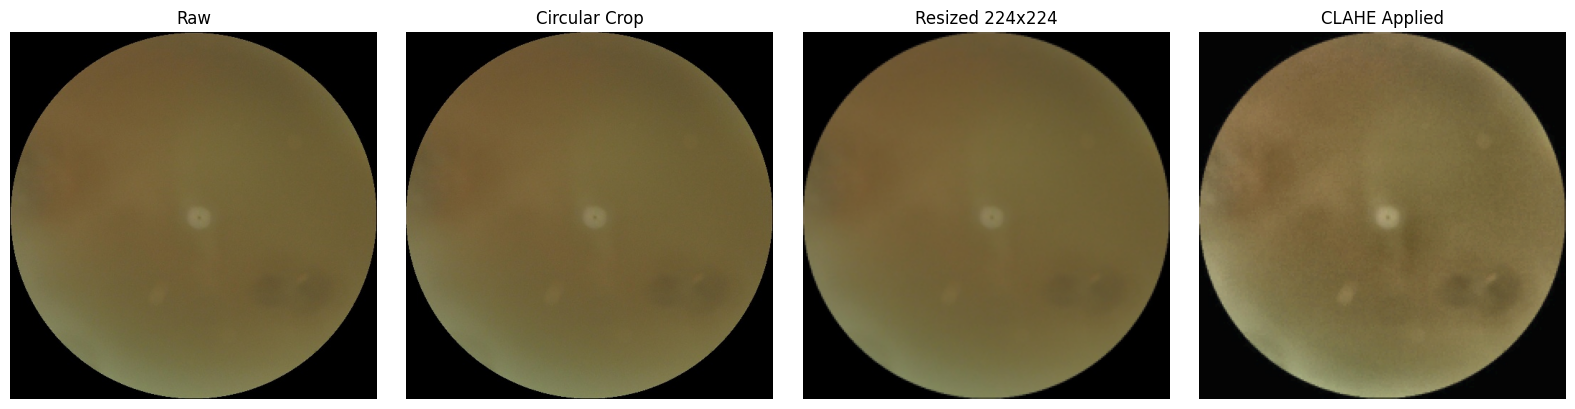

In [24]:
# CELL 3: TEST — visualize preprocessing steps and validate quality checker
import importlib
import preprocessing.image_ops as image_ops
importlib.reload(image_ops)
from preprocessing.image_ops import (
    apply_clahe, circular_retina_crop, resize_image,
    normalize_image, check_image_quality, preprocess_pipeline
)

import cv2
import numpy as np
import matplotlib.pyplot as plt

sample_filename = flat_df.iloc[0]["filename"]
sample_path = os.path.join(IMAGE_DIR, sample_filename)
raw_img = cv2.imread(sample_path)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

cropped = circular_retina_crop(raw_img)
resized = resize_image(cropped, 224)
clahe_img = apply_clahe(resized)
normalized = normalize_image(clahe_img)

assert resized.shape == (224, 224, 3)
assert clahe_img.shape == (224, 224, 3)
assert normalized.dtype == np.float32
print("All preprocessing stages ran successfully.")
print(f"   Raw shape: {raw_img.shape} -> Cropped: {cropped.shape} -> Resized: {resized.shape}")

pipeline_out = preprocess_pipeline(raw_img, img_size=224)
assert pipeline_out.shape == (224, 224, 3)
print("preprocess_pipeline() output shape correct:", pipeline_out.shape)

quality = check_image_quality(resized)
print("Quality check result on real image:", quality)

blurry_dark = np.full((224, 224, 3), 5, dtype=np.uint8)
q_bad = check_image_quality(blurry_dark)
assert q_bad["is_acceptable"] == False
assert q_bad["is_too_dark"] == True
print("Quality checker correctly flags bad synthetic image:", q_bad)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(raw_img); axes[0].set_title("Raw")
axes[1].imshow(cropped); axes[1].set_title("Circular Crop")
axes[2].imshow(resized); axes[2].set_title("Resized 224x224")
axes[3].imshow(clahe_img); axes[3].set_title("CLAHE Applied")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "outputs", "curves", "preprocessing_demo.png"))
plt.show()

## Module 5 — Augmentation

In [25]:
# CELL 1: augmentation/transforms.py — lightweight Albumentations pipelines
transforms_code = """
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def get_train_transform(img_size=224):
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.4, border_mode=0),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
        A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.1, rotate_limit=10,
            border_mode=0, p=0.3,
        ),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def get_val_transform(img_size=224):
    return A.Compose([
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])
"""

with open(os.path.join(PROJECT_ROOT, "augmentation", "transforms.py"), "w") as f:
    f.write(transforms_code)

print("Written: augmentation/transforms.py")

Written: augmentation/transforms.py


In [26]:
# CELL 2: ensure albumentations is available
!pip install -q -U albumentations

import importlib
import augmentation.transforms as transforms_module
importlib.reload(transforms_module)
from augmentation.transforms import get_train_transform, get_val_transform

print("Albumentations pipelines imported successfully.")

Albumentations pipelines imported successfully.


In [27]:
# CELL 3: Build final Dataset objects with the correct transform per split
import importlib.util
import sys
import os
from configs.config import CFG
from augmentation.transforms import get_train_transform, get_val_transform

# 1. Manually load the module to ensure it's in sys.modules before use
module_path = os.path.join(PROJECT_ROOT, "datasets", "odir_dataset.py")
spec = importlib.util.spec_from_file_location("datasets.odir_dataset", module_path)
odir_dataset_mod = importlib.util.module_from_spec(spec)
sys.modules["datasets.odir_dataset"] = odir_dataset_mod
spec.loader.exec_module(odir_dataset_mod)

from datasets.odir_dataset import ODIRDataset

train_transform = get_train_transform(CFG.IMG_SIZE)
val_transform = get_val_transform(CFG.IMG_SIZE)

train_dataset = ODIRDataset(train_df, IMAGE_DIR, img_size=CFG.IMG_SIZE, transform=train_transform)
val_dataset = ODIRDataset(val_df, IMAGE_DIR, img_size=CFG.IMG_SIZE, transform=val_transform)
test_dataset = ODIRDataset(test_df, IMAGE_DIR, img_size=CFG.IMG_SIZE, transform=val_transform)

print(f"Train dataset: {len(train_dataset)} samples (augmented)")
print(f"Val dataset:   {len(val_dataset)} samples (deterministic)")
print(f"Test dataset:  {len(test_dataset)} samples (deterministic)")

Train dataset: 5113 samples (augmented)
Val dataset:   639 samples (deterministic)
Test dataset:  640 samples (deterministic)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Train sample tensor shape/type correct: torch.Size([3, 224, 224]) torch.float32
Val transform is deterministic (no random augmentation).
Train transform produces variation across calls: True
Augmented batch shape correct: torch.Size([8, 3, 224, 224])


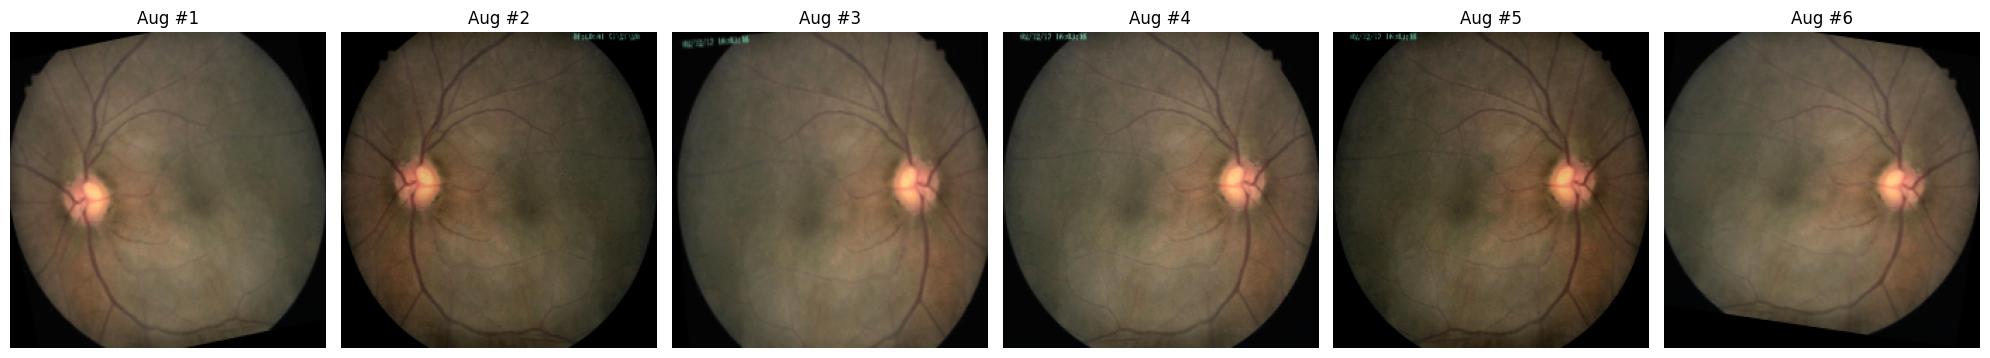

In [28]:
# CELL 4: TEST — verify tensor output and visualize augmentation variety
import torch
import numpy as np
import matplotlib.pyplot as plt

img, label = train_dataset[0]
assert isinstance(img, torch.Tensor)
assert img.shape == (3, CFG.IMG_SIZE, CFG.IMG_SIZE)
assert img.dtype == torch.float32
print("Train sample tensor shape/type correct:", img.shape, img.dtype)

val_img1, _ = val_dataset[0]
val_img2, _ = val_dataset[0]
assert torch.allclose(val_img1, val_img2)
print("Val transform is deterministic (no random augmentation).")

train_img1, _ = train_dataset[0]
train_img2, _ = train_dataset[0]
is_different = not torch.allclose(train_img1, train_img2)
print(f"Train transform produces variation across calls: {is_different}")

from torch.utils.data import DataLoader
loader = DataLoader(
    train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True,
    num_workers=CFG.NUM_WORKERS, pin_memory=CFG.PIN_MEMORY,
    persistent_workers=CFG.PERSISTENT_WORKERS,
)
batch_imgs, batch_labels = next(iter(loader))
assert batch_imgs.shape == (CFG.BATCH_SIZE, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
print("Augmented batch shape correct:", batch_imgs.shape)

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    img = (img * std) + mean
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for i in range(6):
    aug_img, _ = train_dataset[0]
    axes[i].imshow(denormalize(aug_img))
    axes[i].set_title(f"Aug #{i+1}")
    axes[i].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "outputs", "curves", "augmentation_preview.png"))
plt.show()

## Module 6 — Training Pipeline

In [29]:
# CELL 1: install timm
!pip install -q timm

import timm
print("timm version:", timm.__version__)

timm version: 1.0.28


In [30]:
# CELL 2: models/backbone.py — multi-label classification model (minimal, expanded in Module 7)
model_code = """
import torch
import torch.nn as nn
import timm

SUPPORTED_BACKBONES = {
    "efficientnetv2_s": "tf_efficientnetv2_s.in1k",
    "convnext_tiny": "convnext_tiny.fb_in1k",
}

class RetinaClassifier(nn.Module):
    def __init__(self, backbone_name="efficientnetv2_s", num_classes=8, pretrained=True):
        super().__init__()
        assert backbone_name in SUPPORTED_BACKBONES, f"Unsupported backbone: {backbone_name}"

        timm_name = SUPPORTED_BACKBONES[backbone_name]
        self.backbone = timm.create_model(
            timm_name, pretrained=pretrained, num_classes=0
        )
        feat_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(feat_dim, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        logits = self.head(features)
        return logits

    def get_feature_extractor(self):
        return self.backbone
"""

with open(os.path.join(PROJECT_ROOT, "models", "backbone.py"), "w") as f:
    f.write(model_code)

print("Written: models/backbone.py")

Written: models/backbone.py


In [31]:
# CELL 3: losses/losses.py — BCE and Focal Loss for multi-label classification
losses_code = """
import torch
import torch.nn as nn
import torch.nn.functional as F


class WeightedBCELoss(nn.Module):
    def __init__(self, pos_weight=None):
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        return F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight
        )


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction="none"
        )
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        alpha_weight = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_weight * focal_weight * bce
        return loss.mean()


def compute_pos_weight(label_df, disease_cols, device):
    pos_counts = label_df[disease_cols].sum().values
    total = len(label_df)
    neg_counts = total - pos_counts
    pos_weight = neg_counts / (pos_counts + 1e-6)
    pos_weight = pos_weight.clip(max=20.0)
    return torch.tensor(pos_weight, dtype=torch.float32, device=device)


def get_loss_fn(loss_type, pos_weight=None, focal_alpha=0.25, focal_gamma=2.0):
    if loss_type == "bce":
        return WeightedBCELoss(pos_weight=pos_weight)
    elif loss_type == "focal":
        return FocalLoss(alpha=focal_alpha, gamma=focal_gamma, pos_weight=pos_weight)
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")
"""

with open(os.path.join(PROJECT_ROOT, "losses", "losses.py"), "w") as f:
    f.write(losses_code)

print("Written: losses/losses.py")

Written: losses/losses.py


In [32]:
# CELL 4: utils/sampler.py — WeightedRandomSampler for class imbalance
sampler_code = """
import numpy as np
import torch
from torch.utils.data import WeightedRandomSampler


def build_weighted_sampler(label_df, disease_cols):
    class_counts = label_df[disease_cols].sum().values
    class_counts = np.clip(class_counts, 1, None)
    class_weights = 1.0 / class_counts

    labels_matrix = label_df[disease_cols].values

    sample_weights = (labels_matrix * class_weights).max(axis=1)
    sample_weights = np.where(sample_weights == 0, class_weights.min(), sample_weights)

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )
    return sampler
"""

with open(os.path.join(PROJECT_ROOT, "utils", "sampler.py"), "w") as f:
    f.write(sampler_code)

print("Written: utils/sampler.py")

Written: utils/sampler.py


In [33]:
# CELL 5: utils/checkpoint.py — save/load checkpoints to Google Drive
checkpoint_code = """
import torch
import os


def save_checkpoint(path, model, optimizer, scaler, epoch, best_val_loss, early_stop_counter):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict(),
        "best_val_loss": best_val_loss,
        "early_stop_counter": early_stop_counter,
    }, path)


def load_checkpoint(path, model, optimizer=None, scaler=None, device="cuda"):
    if not os.path.exists(path):
        return None

    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optimizer_state" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    if scaler is not None and "scaler_state" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state"])

    return {
        "epoch": ckpt.get("epoch", 0),
        "best_val_loss": ckpt.get("best_val_loss", float("inf")),
        "early_stop_counter": ckpt.get("early_stop_counter", 0),
    }
"""

with open(os.path.join(PROJECT_ROOT, "utils", "checkpoint.py"), "w") as f:
    f.write(checkpoint_code)

print("Written: utils/checkpoint.py")

Written: utils/checkpoint.py


In [34]:
# CELL 6: training/train.py — full training engine
train_code = """
import torch
import torch.nn as nn
import gc
import os
import time
from torch.cuda.amp import autocast, GradScaler

from utils.checkpoint import save_checkpoint, load_checkpoint


def train_one_epoch(model, loader, optimizer, loss_fn, scaler, device, grad_accum_steps, grad_clip_norm):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for step, (images, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=True):
            logits = model(images)
            loss = loss_fn(logits, labels) / grad_accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % grad_accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * grad_accum_steps

    return total_loss / len(loader)


@torch.no_grad()
def validate_one_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast(enabled=True):
            logits = model(images)
            loss = loss_fn(logits, labels)
        total_loss += loss.item()
    return total_loss / len(loader)


def train_model(model, train_loader, val_loader, loss_fn, cfg, device,
                 checkpoint_dir, resume=True):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
    scaler = GradScaler(enabled=cfg.USE_AMP)

    os.makedirs(checkpoint_dir, exist_ok=True)
    last_ckpt_path = os.path.join(checkpoint_dir, "last_checkpoint.pt")
    best_ckpt_path = os.path.join(checkpoint_dir, "best_checkpoint.pt")

    start_epoch = 0
    best_val_loss = float("inf")
    early_stop_counter = 0

    if resume:
        state = load_checkpoint(last_ckpt_path, model, optimizer, scaler, device)
        if state is not None:
            start_epoch = state["epoch"] + 1
            best_val_loss = state["best_val_loss"]
            early_stop_counter = state["early_stop_counter"]
            print(f"Resumed from epoch {start_epoch} (best_val_loss={best_val_loss:.4f})")

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(start_epoch, cfg.EPOCHS):
        t0 = time.time()

        train_loss = train_one_epoch(
            model, train_loader, optimizer, loss_fn, scaler, device,
            cfg.GRAD_ACCUM_STEPS, cfg.GRAD_CLIP_NORM
        )
        val_loss = validate_one_epoch(model, val_loader, loss_fn, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        elapsed = time.time() - t0
        print(f"Epoch {epoch+1}/{cfg.EPOCHS} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | lr={scheduler.get_last_lr()[0]:.2e} | {elapsed:.1f}s")

        save_checkpoint(last_ckpt_path, model, optimizer, scaler, epoch, best_val_loss, early_stop_counter)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            save_checkpoint(best_ckpt_path, model, optimizer, scaler, epoch, best_val_loss, early_stop_counter)
            print(f"   New best model saved (val_loss={val_loss:.4f})")
        else:
            early_stop_counter += 1
            print(f"   No improvement ({early_stop_counter}/{cfg.EARLY_STOPPING_PATIENCE})")

        gc.collect()
        torch.cuda.empty_cache()

        if early_stop_counter >= cfg.EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return history
"""

with open(os.path.join(PROJECT_ROOT, "training", "train.py"), "w") as f:
    f.write(train_code)

print("Written: training/train.py")

Written: training/train.py


In [35]:
# CELL 7: TEST — run a tiny 2-epoch smoke test
import importlib, sys
import torch
from torch.utils.data import DataLoader, Subset

for mod_name in ["models.backbone", "losses.losses", "utils.sampler",
                  "utils.checkpoint", "training.train"]:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

from models.backbone import RetinaClassifier
from losses.losses import get_loss_fn, compute_pos_weight
from utils.sampler import build_weighted_sampler
from training.train import train_model
from configs.config import CFG

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DISEASE_COLS = ["N", "D", "G", "C", "A", "H", "M", "O"]

small_train = Subset(train_dataset, range(32))
small_val = Subset(val_dataset, range(16))

sampler = build_weighted_sampler(train_df.iloc[:32].reset_index(drop=True), DISEASE_COLS)
train_loader_smoke = DataLoader(small_train, batch_size=CFG.BATCH_SIZE, sampler=sampler,
                                 num_workers=0, pin_memory=CFG.PIN_MEMORY)
val_loader_smoke = DataLoader(small_val, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0)

model = RetinaClassifier(backbone_name=CFG.BACKBONE, num_classes=CFG.NUM_CLASSES).to(DEVICE)
pos_weight = compute_pos_weight(train_df, DISEASE_COLS, DEVICE)
loss_fn = get_loss_fn(CFG.LOSS_TYPE, pos_weight=pos_weight)

print(f"Model built: {CFG.BACKBONE} | Params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

sample_batch, sample_labels = next(iter(train_loader_smoke))
sample_batch = sample_batch.to(DEVICE)
with torch.no_grad():
    out = model(sample_batch)
assert out.shape == (sample_batch.shape[0], CFG.NUM_CLASSES)
print("Forward pass shape correct:", out.shape)

loss_val = loss_fn(out, sample_labels.to(DEVICE))
assert torch.isfinite(loss_val)
print(f"Loss computed: {loss_val.item():.4f}")

smoke_ckpt_dir = os.path.join(DRIVE_ROOT, "weights", "smoke_test")
smoke_cfg = CFG
smoke_cfg.EPOCHS = 2
smoke_cfg.EARLY_STOPPING_PATIENCE = 5

history = train_model(model, train_loader_smoke, val_loader_smoke, loss_fn,
                       smoke_cfg, DEVICE, smoke_ckpt_dir, resume=False)

assert len(history["train_loss"]) == 2
assert os.path.exists(os.path.join(smoke_ckpt_dir, "last_checkpoint.pt"))
print("Smoke test complete — training loop, AMP, checkpointing all verified.")
print("History:", history)

model.safetensors: reconstructing file:   0%|          |  0.00B / 86.5MB            

model.safetensors: downloading bytes:           |  0.00B            

Model built: efficientnetv2_s | Params: 20.2M
Forward pass shape correct: torch.Size([8, 8])
Loss computed: 1.3739


/content/project/training/train.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.USE_AMP)
/content/project/training/train.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/training/train.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/training/train.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/training/train.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/tr

Epoch 1/2 | train_loss=1.9658 | val_loss=1.2950 | lr=5.00e-05 | 8.4s
   New best model saved (val_loss=1.2950)


/content/project/training/train.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/training/train.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/training/train.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/training/train.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/training/train.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/training/train.py:

Epoch 2/2 | train_loss=1.5238 | val_loss=1.3130 | lr=0.00e+00 | 1.4s
   No improvement (1/5)
Smoke test complete — training loop, AMP, checkpointing all verified.
History: {'train_loss': [1.965840995311737, 1.523787409067154], 'val_loss': [1.2949519157409668, 1.3129587173461914]}


In [36]:
# SAFETY CHECK — run this BEFORE Cell 8, confirms/fixes models/backbone.py
import os

backbone_path = "/content/project/models/backbone.py"
with open(backbone_path, "r") as f:
    content = f.read()

if "def build_model" not in content:
    print("⚠️ models/backbone.py is still the MINIMAL version (no build_model).")
    print("   -> You must run Module 7, Cell 1 in THIS session first.")
    print("   -> Scroll up to Module 7 and re-run its 'CELL 1: models/backbone.py — FINAL version' cell.")
else:
    print("✅ models/backbone.py already has build_model — Cell 8 should work now.")

⚠️ models/backbone.py is still the MINIMAL version (no build_model).
   -> You must run Module 7, Cell 1 in THIS session first.
   -> Scroll up to Module 7 and re-run its 'CELL 1: models/backbone.py — FINAL version' cell.


In [40]:
# CELL 8: REAL FULL TRAINING — ODIR-5K, two-stage (freeze -> unfreeze), regularized, resumable
# This is the ACTUAL training run (not the smoke test above). It uses the FULL
# train_dataset/val_dataset (not a Subset) and takes real time (several hours on a T4).
# resume=True means re-running this exact cell after a Colab disconnect continues safely
# from the last saved checkpoint instead of starting over.
import importlib, sys, gc
for mod in ["training.train", "models.backbone", "losses.losses", "utils.sampler"]:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from training.train import train_model
from models.backbone import build_model
from losses.losses import get_loss_fn, compute_pos_weight
from utils.sampler import build_weighted_sampler
from torch.utils.data import DataLoader
from configs.config import CFG

DISEASE_COLS = ["N", "D", "G", "C", "A", "H", "M", "O"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

full_sampler = build_weighted_sampler(train_df, DISEASE_COLS)
full_train_loader = DataLoader(
    train_dataset, batch_size=CFG.BATCH_SIZE, sampler=full_sampler,
    num_workers=CFG.NUM_WORKERS, pin_memory=CFG.PIN_MEMORY,
)
full_val_loader = DataLoader(
    val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=CFG.PIN_MEMORY,
)
full_test_loader = DataLoader(
    test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=CFG.PIN_MEMORY,
)

odir_real_model = build_model(CFG, DEVICE)
odir_pos_weight = compute_pos_weight(train_df, DISEASE_COLS, DEVICE)
odir_loss_fn = get_loss_fn(CFG.LOSS_TYPE, pos_weight=odir_pos_weight)

CFG.WEIGHT_DECAY = 5e-4
CFG.EARLY_STOPPING_PATIENCE = 4

# ---- Stage 1: freeze backbone, train only the classifier head ----
odir_real_model.freeze_backbone()
CFG.LR = 3e-5
CFG.EPOCHS = 3
odir_stage1_dir = os.path.join(DRIVE_ROOT, "weights", "odir_real_stage1")
history_odir_s1 = train_model(
    odir_real_model, full_train_loader, full_val_loader,
    odir_loss_fn, CFG, DEVICE, odir_stage1_dir, resume=True,
)

# ---- Stage 2: unfreeze, fine-tune the full model at a lower LR ----
odir_real_model.unfreeze_backbone()
CFG.LR = 1e-5
CFG.EPOCHS = 30
odir_stage2_dir = os.path.join(DRIVE_ROOT, "weights", "odir_real_stage2")
history_odir_s2 = train_model(
    odir_real_model, full_train_loader, full_val_loader,
    odir_loss_fn, CFG, DEVICE, odir_stage2_dir, resume=True,
)

print("ODIR-5K real training complete/stopped.")
print(f"Best checkpoint: {os.path.join(odir_stage2_dir, 'best_checkpoint.pt')}")
gc.collect(); torch.cuda.empty_cache()

Backbone (efficientnetv2_s) frozen — only classifier head will train.


/content/project/training/train.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.USE_AMP)


Resumed from epoch 3 (best_val_loss=1.1100)
Backbone (efficientnetv2_s) unfrozen — full model will train.
Resumed from epoch 13 (best_val_loss=0.8614)


/content/project/training/train.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/training/train.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


Epoch 14/30 | train_loss=0.6415 | val_loss=0.8462 | lr=7.30e-06 | 114.5s
   New best model saved (val_loss=0.8462)
Epoch 15/30 | train_loss=0.6251 | val_loss=0.8499 | lr=7.24e-06 | 110.5s
   No improvement (1/4)
Epoch 16/30 | train_loss=0.6025 | val_loss=0.8397 | lr=7.14e-06 | 110.8s
   New best model saved (val_loss=0.8397)
Epoch 17/30 | train_loss=0.5929 | val_loss=0.8179 | lr=7.00e-06 | 116.3s
   New best model saved (val_loss=0.8179)
Epoch 18/30 | train_loss=0.5694 | val_loss=0.8170 | lr=6.83e-06 | 114.4s
   New best model saved (val_loss=0.8170)
Epoch 19/30 | train_loss=0.5499 | val_loss=0.8209 | lr=6.62e-06 | 114.2s
   No improvement (1/4)
Epoch 20/30 | train_loss=0.5272 | val_loss=0.8054 | lr=6.38e-06 | 106.5s
   New best model saved (val_loss=0.8054)
Epoch 21/30 | train_loss=0.5130 | val_loss=0.7925 | lr=6.11e-06 | 110.9s
   New best model saved (val_loss=0.7925)
Epoch 22/30 | train_loss=0.4972 | val_loss=0.7850 | lr=5.81e-06 | 110.6s
   New best model saved (val_loss=0.7850)
E

In [41]:
# ফোল্ডার নিশ্চিত করা — save করার আগে
import os
for sub in ["curves", "confusion_matrix", "gradcam_images", "predictions"]:
    os.makedirs(os.path.join(DRIVE_ROOT, "outputs", sub), exist_ok=True)
print("Folders ready.")

Folders ready.


In [48]:
# CELL 9: RE-EVALUATE with the REAL checkpoint (replaces the smoke-test numbers from Module 8)
from evaluation.metrics import compute_all_metrics, print_metrics_report
from evaluation.inference import run_inference
from evaluation.plots import plot_training_curves, plot_confusion_matrices, plot_roc_curves
from utils.checkpoint import load_checkpoint

DISEASE_COLS = ["N", "D", "G", "C", "A", "H", "M", "O"]
OUTPUTS_DIR = os.path.join(DRIVE_ROOT, "outputs")

real_eval_model = build_model(CFG, DEVICE)
real_ckpt_path = os.path.join(DRIVE_ROOT, "weights", "odir_real_stage2", "best_checkpoint.pt")
state = load_checkpoint(real_ckpt_path, real_eval_model, device=DEVICE)
assert state is not None, "Real ODIR checkpoint not found — run CELL 8 above first."
print(f"Loaded REAL checkpoint from epoch {state['epoch']}")

y_true, y_pred_probs, _ = run_inference(real_eval_model, full_test_loader, DEVICE)
results = compute_all_metrics(y_true, y_pred_probs, DISEASE_COLS, threshold=0.7)
print_metrics_report(results, DISEASE_COLS)

combined_history = {
    "train_loss": history_odir_s1["train_loss"] + history_odir_s2["train_loss"],
    "val_loss": history_odir_s1["val_loss"] + history_odir_s2["val_loss"],
}
plot_training_curves(combined_history, os.path.join(OUTPUTS_DIR, "curves", "loss_curve_REAL.png"))
plot_confusion_matrices(results["per_class"], DISEASE_COLS,
                          os.path.join(OUTPUTS_DIR, "confusion_matrix", "confusion_matrix_REAL.png"))
plot_roc_curves(y_true, y_pred_probs, DISEASE_COLS,
                 os.path.join(OUTPUTS_DIR, "curves", "roc_curve_REAL.png"))
print("Real evaluation plots saved (suffixed _REAL to distinguish from the earlier smoke-test plots).")

Loaded REAL checkpoint from epoch 23


/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


Class               Acc    Prec  Recall    Spec      F1     AUC
---------------------------------------------------------------
N                 0.688   0.545   0.089   0.966   0.153   0.735
D                 0.711   0.740   0.177   0.970   0.286   0.732
G                 0.892   0.289   0.595   0.910   0.389   0.908
C                 0.889   0.390   0.854   0.892   0.536   0.947
A                 0.894   0.375   0.717   0.907   0.493   0.902
H                 0.897   0.113   0.727   0.900   0.195   0.941
M                 0.969   0.487   1.000   0.968   0.655   1.000
O                 0.738   0.333   0.037   0.975   0.067   0.593
---------------------------------------------------------------
MACRO AVG         0.835   0.409   0.525   0.936   0.347   0.845
Subset Accuracy (exact multi-label match): 0.170
Real evaluation plots saved (suffixed _REAL to distinguish from the earlier smoke-test plots).


In [49]:
# NEW CELL — Per-class threshold tuning (Cell 9 এর পরে চালান)
import numpy as np
from sklearn.metrics import f1_score

# val set দিয়ে logits/probs বের করা (test set না — leakage এড়াতে)
val_true, val_probs, _ = run_inference(real_eval_model, full_val_loader, DEVICE)

best_thresholds = {}
for i, cname in enumerate(DISEASE_COLS):
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.1, 0.95, 0.05):
        pred = (val_probs[:, i] >= t).astype(int)
        f1 = f1_score(val_true[:, i], pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresholds[cname] = round(best_t, 2)

print("প্রতিটা ক্লাসের সেরা threshold:")
print(best_thresholds)

# test set-এ এই per-class threshold দিয়ে prediction
y_pred_custom = np.zeros_like(y_pred_probs, dtype=int)
for i, cname in enumerate(DISEASE_COLS):
    y_pred_custom[:, i] = (y_pred_probs[:, i] >= best_thresholds[cname]).astype(int)

print("\nDone — y_pred_custom তৈরি হয়ে গেছে।")

/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


প্রতিটা ক্লাসের সেরা threshold:
{'N': np.float64(0.35), 'D': np.float64(0.45), 'G': np.float64(0.9), 'C': np.float64(0.9), 'A': np.float64(0.85), 'H': np.float64(0.9), 'M': np.float64(0.9), 'O': np.float64(0.35)}

Done — y_pred_custom তৈরি হয়ে গেছে।


In [50]:
# NEW CELL — per-class threshold দিয়ে metrics দেখা
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, accuracy_score

print(f"{'Class':<10}{'Prec':>8}{'Recall':>8}{'F1':>8}{'Threshold':>12}")
print("-" * 46)
for i, cname in enumerate(DISEASE_COLS):
    yt = y_true[:, i]
    yp = y_pred_custom[:, i]
    prec = precision_score(yt, yp, zero_division=0)
    rec = recall_score(yt, yp, zero_division=0)
    f1 = f1_score(yt, yp, zero_division=0)
    print(f"{cname:<10}{prec:>8.3f}{rec:>8.3f}{f1:>8.3f}{best_thresholds[cname]:>12}")

subset_acc = accuracy_score(y_true, y_pred_custom)
print(f"\nSubset Accuracy (per-class threshold): {subset_acc:.3f}")

Class         Prec  Recall      F1   Threshold
----------------------------------------------
N            0.441   0.892   0.591        0.35
D            0.463   0.751   0.573        0.45
G            0.444   0.432   0.438         0.9
C            0.678   0.833   0.748         0.9
A            0.544   0.674   0.602        0.85
H            0.188   0.545   0.279         0.9
M            0.731   1.000   0.844         0.9
O            0.275   0.852   0.416        0.35

Subset Accuracy (per-class threshold): 0.117


## Module 7 — Model (Full Expansion)

In [38]:
# CELL 1: models/backbone.py — FINAL version with freeze/unfreeze + GradCAM layer exposure
model_code = """
import torch
import torch.nn as nn
import timm

SUPPORTED_BACKBONES = {
    "efficientnetv2_s": "tf_efficientnetv2_s.in1k",
    "convnext_tiny": "convnext_tiny.fb_in1k",
}

GRADCAM_LAYER_PATHS = {
    "efficientnetv2_s": "conv_head",
    "convnext_tiny": "stages.3",
}


class RetinaClassifier(nn.Module):
    def __init__(self, backbone_name="efficientnetv2_s", num_classes=8, pretrained=True):
        super().__init__()
        assert backbone_name in SUPPORTED_BACKBONES, f"Unsupported backbone: {backbone_name}"
        self.backbone_name = backbone_name

        timm_name = SUPPORTED_BACKBONES[backbone_name]
        self.backbone = timm.create_model(
            timm_name, pretrained=pretrained, num_classes=0
        )
        feat_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(feat_dim, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        logits = self.head(features)
        return logits

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        print(f"Backbone ({self.backbone_name}) frozen — only classifier head will train.")

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
        print(f"Backbone ({self.backbone_name}) unfrozen — full model will train.")

    def count_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def count_total_params(self):
        return sum(p.numel() for p in self.parameters())

    def get_target_layer(self):
        path = GRADCAM_LAYER_PATHS[self.backbone_name]
        module = self.backbone
        for attr in path.split("."):
            module = getattr(module, attr) if not attr.isdigit() else module[int(attr)]
        return module


def build_model(cfg, device="cuda"):
    model = RetinaClassifier(
        backbone_name=cfg.BACKBONE,
        num_classes=cfg.NUM_CLASSES,
        pretrained=cfg.PRETRAINED,
    )
    return model.to(device)
"""

with open(os.path.join(PROJECT_ROOT, "models", "backbone.py"), "w") as f:
    f.write(model_code)

print("Written: models/backbone.py (final version)")

Written: models/backbone.py (final version)


In [39]:
# CELL 2: Reload and instantiate both supported backbones for comparison
import importlib, sys
if "models.backbone" in sys.modules:
    importlib.reload(sys.modules["models.backbone"])

from models.backbone import RetinaClassifier, build_model, SUPPORTED_BACKBONES
from configs.config import CFG

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Building both backbone variants for comparison...")

models_compare = {}
for backbone_name in SUPPORTED_BACKBONES.keys():
    m = RetinaClassifier(backbone_name=backbone_name, num_classes=CFG.NUM_CLASSES, pretrained=True).to(DEVICE)
    models_compare[backbone_name] = m
    total_params = m.count_total_params()
    trainable_params = m.count_trainable_params()
    print(f"[{backbone_name}]")
    print(f"   Total params:     {total_params/1e6:.2f}M")
    print(f"   Trainable params: {trainable_params/1e6:.2f}M")
    print(f"   Target GradCAM layer: {m.get_target_layer().__class__.__name__}")

Building both backbone variants for comparison...
[efficientnetv2_s]
   Total params:     20.19M
   Trainable params: 20.19M
   Target GradCAM layer: Conv2d


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

[convnext_tiny]
   Total params:     27.83M
   Trainable params: 27.83M
   Target GradCAM layer: ConvNeXtStage


In [ ]:
# CELL 3: Measure actual peak GPU memory for a training-shaped forward+backward pass
import torch
import gc

def measure_peak_memory(model, batch_size, img_size, device):
    if device != "cuda":
        print("No GPU — skipping memory measurement.")
        return None

    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.empty_cache()

    model.train()
    dummy_input = torch.randn(batch_size, 3, img_size, img_size, device=device)
    dummy_labels = torch.randint(0, 2, (batch_size, CFG.NUM_CLASSES), device=device).float()

    from torch.cuda.amp import autocast, GradScaler
    scaler = GradScaler()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    with autocast():
        logits = model(dummy_input)
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, dummy_labels)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    peak_mb = torch.cuda.max_memory_allocated(device) / 1e6
    return peak_mb


print("Peak GPU memory usage per backbone (batch_size=8, AMP enabled):")
for name, m in models_compare.items():
    peak = measure_peak_memory(m, CFG.BATCH_SIZE, CFG.IMG_SIZE, DEVICE)
    if peak is not None:
        print(f"[{name}] Peak VRAM: {peak:.1f} MB ({peak/1024:.2f} GB)")
    torch.cuda.empty_cache()
    gc.collect()

Peak GPU memory usage per backbone (batch_size=8, AMP enabled):
[efficientnetv2_s] Peak VRAM: 977.2 MB (0.95 GB)


/tmp/ipykernel_1188/626014379.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_1188/626014379.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[convnext_tiny] Peak VRAM: 968.6 MB (0.95 GB)


In [ ]:
# CELL 4: TEST — full validation of Module 7 model behavior
import torch
import gc

model = build_model(CFG, DEVICE)

dummy = torch.randn(4, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)
out = model(dummy)
assert out.shape == (4, CFG.NUM_CLASSES)
print("Forward pass shape correct:", out.shape)

model.freeze_backbone()
frozen_trainable = model.count_trainable_params()
assert frozen_trainable < model.count_total_params()
print(f"After freeze: trainable={frozen_trainable/1e6:.2f}M / total={model.count_total_params()/1e6:.2f}M")

model.unfreeze_backbone()
unfrozen_trainable = model.count_trainable_params()
assert unfrozen_trainable == model.count_total_params()
print(f"After unfreeze: trainable={unfrozen_trainable/1e6:.2f}M (== total)")

target_layer = model.get_target_layer()
assert isinstance(target_layer, torch.nn.Module)
print(f"GradCAM target layer resolved: {type(target_layer).__name__}")

activations = {}
def hook_fn(module, input, output):
    activations["value"] = output

handle = target_layer.register_forward_hook(hook_fn)
_ = model(dummy)
handle.remove()
assert "value" in activations
print(f"Forward hook captured activation shape: {activations['value'].shape}")

factory_model = build_model(CFG, DEVICE)
factory_out = factory_model(dummy)
assert factory_out.shape == (4, CFG.NUM_CLASSES)
print("build_model() factory works correctly from config alone.")

del models_compare, model, factory_model
gc.collect()
torch.cuda.empty_cache()
print("All Module 7 model tests passed. Memory cleared.")

Forward pass shape correct: torch.Size([4, 8])
Backbone (efficientnetv2_s) frozen — only classifier head will train.
After freeze: trainable=0.01M / total=20.19M
Backbone (efficientnetv2_s) unfrozen — full model will train.
After unfreeze: trainable=20.19M (== total)
GradCAM target layer resolved: Conv2d
Forward hook captured activation shape: torch.Size([4, 1280, 7, 7])
build_model() factory works correctly from config alone.
All Module 7 model tests passed. Memory cleared.


## Module 8 — Evaluation

In [44]:
# CELL 1: evaluation/metrics.py — full multi-label metric suite
metrics_code = """
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, accuracy_score
)


def compute_all_metrics(y_true, y_pred_probs, class_names, threshold=0.5):
    y_pred = (y_pred_probs >= threshold).astype(int)

    per_class = {}
    for i, cname in enumerate(class_names):
        yt = y_true[:, i]
        yp = y_pred[:, i]
        yp_prob = y_pred_probs[:, i]

        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

        precision = precision_score(yt, yp, zero_division=0)
        recall = recall_score(yt, yp, zero_division=0)
        specificity = tn / (tn + fp + 1e-8)
        f1 = f1_score(yt, yp, zero_division=0)
        acc = accuracy_score(yt, yp)

        try:
            auc = roc_auc_score(yt, yp_prob) if len(np.unique(yt)) > 1 else float("nan")
        except ValueError:
            auc = float("nan")

        per_class[cname] = {
            "accuracy": acc, "precision": precision, "recall_sensitivity": recall,
            "specificity": specificity, "f1": f1, "roc_auc": auc,
            "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        }

    macro = {
        metric_key: float(np.nanmean([per_class[c][metric_key] for c in class_names]))
        for metric_key in ["accuracy", "precision", "recall_sensitivity", "specificity", "f1", "roc_auc"]
    }

    subset_accuracy = accuracy_score(y_true, y_pred)

    return {
        "per_class": per_class,
        "macro_avg": macro,
        "subset_accuracy": subset_accuracy,
    }


def print_metrics_report(results, class_names):
    header = "Class".ljust(15) + "Acc".rjust(8) + "Prec".rjust(8) + "Recall".rjust(8) + "Spec".rjust(8) + "F1".rjust(8) + "AUC".rjust(8)
    print(header)
    print("-" * 63)
    for cname in class_names:
        m = results["per_class"][cname]
        print(f"{cname:<15}{m['accuracy']:>8.3f}{m['precision']:>8.3f}"
              f"{m['recall_sensitivity']:>8.3f}{m['specificity']:>8.3f}"
              f"{m['f1']:>8.3f}{m['roc_auc']:>8.3f}")
    print("-" * 63)
    m = results["macro_avg"]
    print("MACRO AVG".ljust(15) + f"{m['accuracy']:>8.3f}{m['precision']:>8.3f}"
          f"{m['recall_sensitivity']:>8.3f}{m['specificity']:>8.3f}"
          f"{m['f1']:>8.3f}{m['roc_auc']:>8.3f}")
    print(f"Subset Accuracy (exact multi-label match): {results['subset_accuracy']:.3f}")
"""

with open(os.path.join(PROJECT_ROOT, "evaluation", "metrics.py"), "w") as f:
    f.write(metrics_code)

print("Written: evaluation/metrics.py")

Written: evaluation/metrics.py


In [45]:
# CELL 2: evaluation/inference.py — run model over a loader, collect probs + labels
inference_code = """
import torch
import numpy as np
from torch.cuda.amp import autocast


@torch.no_grad()
def run_inference(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []
    all_filenames = []

    for batch in loader:
        if len(batch) == 3:
            images, labels, filenames = batch
            all_filenames.extend(filenames)
        else:
            images, labels = batch

        images = images.to(device, non_blocking=True)
        with autocast(enabled=True):
            logits = model(images)
        probs = torch.sigmoid(logits).float().cpu().numpy()

        all_probs.append(probs)
        all_labels.append(labels.numpy())

    y_pred_probs = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_labels, axis=0)

    return y_true, y_pred_probs, all_filenames
"""

with open(os.path.join(PROJECT_ROOT, "evaluation", "inference.py"), "w") as f:
    f.write(inference_code)

print("Written: evaluation/inference.py")

Written: evaluation/inference.py


In [46]:
# CELL 3: evaluation/plots.py — training curves, confusion matrix grid, ROC curves
plots_code = """
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc


def plot_training_curves(history, save_path):
    fig, axes = plt.subplots(1, 1, figsize=(8, 5))
    axes.plot(history["train_loss"], label="Train Loss", marker="o")
    axes.plot(history["val_loss"], label="Val Loss", marker="o")
    axes.set_xlabel("Epoch")
    axes.set_ylabel("Loss")
    axes.set_title("Training & Validation Loss")
    axes.legend()
    axes.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()


def plot_confusion_matrices(per_class_results, class_names, save_path):
    n = len(class_names)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    for i, cname in enumerate(class_names):
        m = per_class_results[cname]
        cm = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
        ax = axes[i]
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(cname)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Neg", "Pos"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["Neg", "Pos"])
        for r in range(2):
            for c in range(2):
                ax.text(c, r, cm[r, c], ha="center", va="center",
                         color="white" if cm[r, c] > cm.max() / 2 else "black")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()


def plot_roc_curves(y_true, y_pred_probs, class_names, save_path):
    plt.figure(figsize=(8, 7))
    for i, cname in enumerate(class_names):
        if len(np.unique(y_true[:, i])) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc_val:.3f})")

    plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (per class)")
    plt.legend(loc="lower right", fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
"""

with open(os.path.join(PROJECT_ROOT, "evaluation", "plots.py"), "w") as f:
    f.write(plots_code)

print("Written: evaluation/plots.py")

Written: evaluation/plots.py


In [47]:
# CELL 4: TEST — run full evaluation on smoke-trained model
import importlib, sys
for mod in ["evaluation.metrics", "evaluation.inference", "evaluation.plots"]:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from evaluation.metrics import compute_all_metrics, print_metrics_report
from evaluation.inference import run_inference
from evaluation.plots import plot_training_curves, plot_confusion_matrices, plot_roc_curves
from models.backbone import build_model
from utils.checkpoint import load_checkpoint
from torch.utils.data import DataLoader, Subset

DISEASE_COLS = ["N", "D", "G", "C", "A", "H", "M", "O"]
OUTPUTS_DIR = os.path.join(DRIVE_ROOT, "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

eval_model = build_model(CFG, DEVICE)
smoke_ckpt_path = os.path.join(DRIVE_ROOT, "weights", "smoke_test", "best_checkpoint.pt")
state = load_checkpoint(smoke_ckpt_path, eval_model, device=DEVICE)
assert state is not None, "Smoke checkpoint not found — re-run Module 6 first."
print(f"Loaded smoke checkpoint from epoch {state['epoch']}")

small_test = Subset(test_dataset, range(min(32, len(test_dataset))))
test_loader_smoke = DataLoader(small_test, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0)

y_true, y_pred_probs, _ = run_inference(eval_model, test_loader_smoke, DEVICE)
assert y_true.shape == y_pred_probs.shape
assert y_pred_probs.min() >= 0 and y_pred_probs.max() <= 1
print(f"Inference collected: y_true {y_true.shape}, y_pred_probs {y_pred_probs.shape}")

results = compute_all_metrics(y_true, y_pred_probs, DISEASE_COLS, threshold=0.5)
assert "per_class" in results and "macro_avg" in results
print_metrics_report(results, DISEASE_COLS)

dummy_history = {"train_loss": [0.80, 0.76, 0.71], "val_loss": [0.75, 0.73, 0.70]}
curves_path = os.path.join(OUTPUTS_DIR, "curves", "loss_curve_test.png")
os.makedirs(os.path.dirname(curves_path), exist_ok=True)
plot_training_curves(dummy_history, curves_path)
assert os.path.exists(curves_path)
print(f"Training curve saved: {curves_path}")

cm_path = os.path.join(OUTPUTS_DIR, "confusion_matrix", "confusion_matrix_test.png")
os.makedirs(os.path.dirname(cm_path), exist_ok=True)
plot_confusion_matrices(results["per_class"], DISEASE_COLS, cm_path)
assert os.path.exists(cm_path)
print(f"Confusion matrix grid saved: {cm_path}")

roc_path = os.path.join(OUTPUTS_DIR, "curves", "roc_curve_test.png")
plot_roc_curves(y_true, y_pred_probs, DISEASE_COLS, roc_path)
assert os.path.exists(roc_path)
print(f"ROC curve saved: {roc_path}")

print("All Module 8 evaluation tests passed.")

Loaded smoke checkpoint from epoch 0


/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


Inference collected: y_true (32, 8), y_pred_probs (32, 8)
Class               Acc    Prec  Recall    Spec      F1     AUC
---------------------------------------------------------------
N                 0.594   0.375   0.273   0.762   0.316   0.522
D                 0.406   0.345   1.000   0.136   0.513   0.609
G                 0.062   0.000   0.000   0.065   0.000   0.032
C                 0.438   0.056   0.500   0.433   0.100   0.500
A                 0.250   0.080   0.667   0.207   0.143   0.397
H                 0.250   0.000   0.000   0.258   0.000   0.129
M                 0.031   0.031   1.000   0.000   0.061   0.226
O                 0.500   0.238   1.000   0.407   0.385   0.574
---------------------------------------------------------------
MACRO AVG         0.316   0.141   0.555   0.284   0.190   0.374
Subset Accuracy (exact multi-label match): 0.000
Training curve saved: /content/drive/MyDrive/retinal_disease_project/outputs/curves/loss_curve_test.png
Confusion matrix grid

## Module 9 — GradCAM

In [51]:
# CELL 1: gradcam/gradcam.py — core GradCAM implementation (multi-label, per-class)
gradcam_code = """
import torch
import torch.nn.functional as F
import numpy as np
import cv2


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_handle = target_layer.register_forward_hook(self._save_activation)
        self.bwd_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def generate(self, input_tensor, target_class):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        logits = self.model(input_tensor)
        self.model.zero_grad()

        class_score = logits[0, target_class]
        class_score.backward(retain_graph=True)

        activations = self.activations[0]
        gradients = self.gradients[0]

        alpha = gradients.mean(dim=(1, 2))
        weighted_sum = torch.einsum("c,chw->hw", alpha, activations)

        heatmap = F.relu(weighted_sum)
        heatmap = heatmap.cpu().numpy()

        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        h_out, w_out = input_tensor.shape[2], input_tensor.shape[3]
        heatmap = cv2.resize(heatmap, (w_out, h_out))

        return heatmap


def overlay_heatmap(original_rgb_uint8, heatmap, alpha=0.4):
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(original_rgb_uint8, 1 - alpha, heatmap_color, alpha, 0)
    return overlay
"""

with open(os.path.join(PROJECT_ROOT, "gradcam", "gradcam.py"), "w") as f:
    f.write(gradcam_code)

print("Written: gradcam/gradcam.py")

Written: gradcam/gradcam.py


In [52]:
# CELL 2: gradcam/explain.py — generate GradCAM for the model's top predicted classes
explain_code = """
import torch
import numpy as np
from gradcam.gradcam import GradCAM, overlay_heatmap


def explain_prediction(model, input_tensor, original_rgb_uint8, class_names,
                         target_layer, threshold=0.5, device="cuda"):
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.sigmoid(logits)[0].cpu().numpy()

    predicted_indices = np.where(probs >= threshold)[0]

    if len(predicted_indices) == 0:
        predicted_indices = [int(np.argmax(probs))]

    results = []
    cam = GradCAM(model, target_layer)

    for idx in predicted_indices:
        heatmap = cam.generate(input_tensor, target_class=int(idx))
        overlay = overlay_heatmap(original_rgb_uint8, heatmap)
        results.append({
            "class_name": class_names[idx],
            "confidence": float(probs[idx]),
            "heatmap": heatmap,
            "overlay": overlay,
        })

    cam.remove_hooks()
    return results, probs
"""

with open(os.path.join(PROJECT_ROOT, "gradcam", "explain.py"), "w") as f:
    f.write(explain_code)

print("Written: gradcam/explain.py")

Written: gradcam/explain.py


Single-class heatmap shape correct: (224, 224), range [0.000, 1.000]
Overlay generated: shape (224, 224, 3), dtype uint8
explain_prediction() returned 3 class explanation(s)
   D: confidence=0.833
   H: confidence=0.849
   O: confidence=0.635
Saved 3 GradCAM image(s) to /content/drive/MyDrive/retinal_disease_project/outputs/gradcam_images


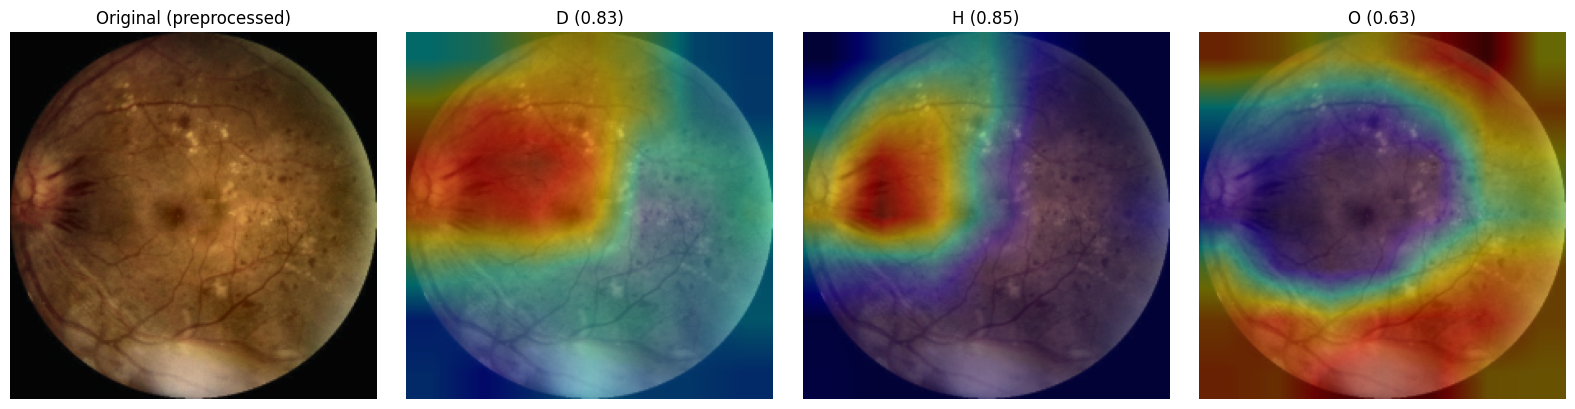

All Module 9 GradCAM tests passed.


In [53]:
# CELL 3: TEST — generate and save real GradCAM heatmaps
import importlib, sys
for mod in ["gradcam.gradcam", "gradcam.explain"]:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from gradcam.gradcam import GradCAM, overlay_heatmap
from gradcam.explain import explain_prediction
from preprocessing.image_ops import preprocess_pipeline, normalize_image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

DISEASE_COLS = ["N", "D", "G", "C", "A", "H", "M", "O"]
gradcam_out_dir = os.path.join(DRIVE_ROOT, "outputs", "gradcam_images")
os.makedirs(gradcam_out_dir, exist_ok=True)

target_layer = real_eval_model.get_target_layer()

sample_filename = test_df.iloc[0]["filename"]
sample_path = os.path.join(IMAGE_DIR, sample_filename)
raw_img = cv2.imread(sample_path)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

processed_uint8 = preprocess_pipeline(raw_img, img_size=CFG.IMG_SIZE)
normalized = normalize_image(processed_uint8)
input_tensor = torch.from_numpy(normalized.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)

cam = GradCAM(real_eval_model, target_layer)
heatmap = cam.generate(input_tensor, target_class=0)
assert heatmap.shape == (CFG.IMG_SIZE, CFG.IMG_SIZE)
assert heatmap.min() >= 0 and heatmap.max() <= 1.0001
cam.remove_hooks()
print(f"Single-class heatmap shape correct: {heatmap.shape}, range [{heatmap.min():.3f}, {heatmap.max():.3f}]")

overlay = overlay_heatmap(processed_uint8, heatmap)
assert overlay.shape == processed_uint8.shape
assert overlay.dtype == np.uint8
print(f"Overlay generated: shape {overlay.shape}, dtype {overlay.dtype}")

results, all_probs = explain_prediction(
    real_eval_model, input_tensor, processed_uint8, DISEASE_COLS,
    target_layer, threshold=0.3, device=DEVICE
)
assert len(results) >= 1
print(f"explain_prediction() returned {len(results)} class explanation(s)")
for r in results:
    print(f"   {r['class_name']}: confidence={r['confidence']:.3f}")

for r in results:
    save_name = f"{sample_filename.split('.')[0]}_{r['class_name']}_gradcam.png"
    save_path = os.path.join(gradcam_out_dir, save_name)
    cv2.imwrite(save_path, cv2.cvtColor(r["overlay"], cv2.COLOR_RGB2BGR))
    assert os.path.exists(save_path)
print(f"Saved {len(results)} GradCAM image(s) to {gradcam_out_dir}")

n_show = min(len(results), 3)
fig, axes = plt.subplots(1, n_show + 1, figsize=(4 * (n_show + 1), 4))
axes[0].imshow(processed_uint8); axes[0].set_title("Original (preprocessed)")
axes[0].axis("off")
for i in range(n_show):
    axes[i + 1].imshow(results[i]["overlay"])
    axes[i + 1].set_title(f"{results[i]['class_name']} ({results[i]['confidence']:.2f})")
    axes[i + 1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(gradcam_out_dir, "gradcam_test_preview.png"))
plt.show()

print("All Module 9 GradCAM tests passed.")

In [54]:
# per-class threshold অনুযায়ী আসল detected disease বের করা
truly_detected = [DISEASE_COLS[i] for i, p in enumerate(all_probs)
                   if p >= best_thresholds[DISEASE_COLS[i]]]
print("Per-class threshold অনুযায়ী প্রকৃত detected:", truly_detected)

Per-class threshold অনুযায়ী প্রকৃত detected: ['D', 'O']


## Module 10 — Prediction (End of Stage 1)

In [55]:
# CELL 1: prediction/predictor.py — end-to-end single-image prediction
os.makedirs(os.path.join(PROJECT_ROOT, "prediction"), exist_ok=True)
open(os.path.join(PROJECT_ROOT, "prediction", "__init__.py"), "a").close()

predictor_code = """
import os
import cv2
import torch
import numpy as np
import pandas as pd
from datetime import datetime

from models.backbone import build_model
from utils.checkpoint import load_checkpoint
from preprocessing.image_ops import preprocess_pipeline, normalize_image, check_image_quality
from gradcam.gradcam import GradCAM, overlay_heatmap

DISEASE_COLS = ["N", "D", "G", "C", "A", "H", "M", "O"]
DISEASE_FULL_NAMES = {
    "N": "Normal", "D": "Diabetic Retinopathy", "G": "Glaucoma",
    "C": "Cataract", "A": "Age-related Macular Degeneration",
    "H": "Hypertension", "M": "Myopia", "O": "Other",
}


class RetinaPredictor:
    def __init__(self, cfg, checkpoint_path, device=None, gradcam_out_dir=None, csv_log_path=None):
        self.cfg = cfg
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.model = build_model(cfg, self.device)
        state = load_checkpoint(checkpoint_path, self.model, device=self.device)
        assert state is not None, f"Checkpoint not found at {checkpoint_path}"
        self.model.eval()

        self.target_layer = self.model.get_target_layer()

        self.gradcam_out_dir = gradcam_out_dir or "outputs/gradcam_images"
        os.makedirs(self.gradcam_out_dir, exist_ok=True)

        self.csv_log_path = csv_log_path or "outputs/predictions/prediction_log.csv"
        os.makedirs(os.path.dirname(self.csv_log_path), exist_ok=True)

        print(f"RetinaPredictor ready | backbone={cfg.BACKBONE} | "
              f"checkpoint epoch={state['epoch']} | device={self.device}")

    def _load_and_preprocess(self, image_path):
        raw_bgr = cv2.imread(image_path)
        if raw_bgr is None:
            raise ValueError(f"Could not read image: {image_path}")
        raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)

        quality = check_image_quality(raw_rgb)
        processed_uint8 = preprocess_pipeline(raw_rgb, img_size=self.cfg.IMG_SIZE)

        normalized = normalize_image(processed_uint8)
        tensor = torch.from_numpy(normalized.transpose(2, 0, 1)).float().unsqueeze(0).to(self.device)

        return tensor, processed_uint8, quality

    def predict(self, image_path, threshold=0.5, save_gradcam=True, log_to_csv=True):
        input_tensor, processed_uint8, quality = self._load_and_preprocess(image_path)

        with torch.no_grad():
            logits = self.model(input_tensor)
            probs = torch.sigmoid(logits)[0].cpu().numpy()

        all_confidences = {code: float(probs[i]) for i, code in enumerate(DISEASE_COLS)}
        detected_indices = np.where(probs >= threshold)[0]
        if len(detected_indices) == 0:
            detected_indices = [int(np.argmax(probs))]

        detected_diseases = []
        base_name = os.path.splitext(os.path.basename(image_path))[0]

        for idx in detected_indices:
            code = DISEASE_COLS[idx]
            entry = {
                "name": DISEASE_FULL_NAMES[code],
                "code": code,
                "confidence": float(probs[idx]),
                "gradcam_path": None,
            }

            if save_gradcam:
                cam = GradCAM(self.model, self.target_layer)
                heatmap = cam.generate(input_tensor, target_class=int(idx))
                overlay = overlay_heatmap(processed_uint8, heatmap)
                cam.remove_hooks()

                save_name = f"{base_name}_{code}_gradcam.png"
                save_path = os.path.join(self.gradcam_out_dir, save_name)
                cv2.imwrite(save_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
                entry["gradcam_path"] = save_path

            detected_diseases.append(entry)

        result = {
            "image_path": image_path,
            "quality_warning": not quality["is_acceptable"],
            "quality_details": quality,
            "detected_diseases": detected_diseases,
            "all_confidences": all_confidences,
        }

        if log_to_csv:
            self._log_prediction(result)

        return result

    def _log_prediction(self, result):
        row = {
            "timestamp": datetime.now().isoformat(),
            "image_path": result["image_path"],
            "quality_warning": result["quality_warning"],
            "detected_codes": ",".join([d["code"] for d in result["detected_diseases"]]),
            "detected_names": ",".join([d["name"] for d in result["detected_diseases"]]),
        }
        row.update({f"prob_{k}": v for k, v in result["all_confidences"].items()})

        df_row = pd.DataFrame([row])
        if os.path.exists(self.csv_log_path):
            df_row.to_csv(self.csv_log_path, mode="a", header=False, index=False)
        else:
            df_row.to_csv(self.csv_log_path, mode="w", header=True, index=False)
"""

with open(os.path.join(PROJECT_ROOT, "prediction", "predictor.py"), "w") as f:
    f.write(predictor_code)

print("Written: prediction/predictor.py")

Written: prediction/predictor.py


In [56]:
# CELL 2: prediction/report.py — human-readable console/report formatting
report_code = """
def print_prediction_report(result):
    print("=" * 60)
    print(f"PREDICTION REPORT — {result['image_path']}")
    print("=" * 60)

    if result["quality_warning"]:
        q = result["quality_details"]
        print(f"IMAGE QUALITY WARNING: {q}")
        print("-" * 60)

    print("Detected Disease(s):")
    for d in result["detected_diseases"]:
        bar = "#" * int(d["confidence"] * 20)
        print(f"  [{d['code']}] {d['name']:<35} {d['confidence']*100:5.1f}%  {bar}")
        if d["gradcam_path"]:
            print(f"        GradCAM saved: {d['gradcam_path']}")

    print("-" * 60)
    print("All class probabilities:")
    for code, prob in result["all_confidences"].items():
        print(f"  {code}: {prob:.3f}")
    print("=" * 60)
"""

with open(os.path.join(PROJECT_ROOT, "prediction", "report.py"), "w") as f:
    f.write(report_code)

print("Written: prediction/report.py")

Written: prediction/report.py


In [57]:
# CELL 3: TEST — instantiate RetinaPredictor and run a real prediction end-to-end
import importlib, sys
for mod in ["prediction.predictor", "prediction.report"]:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from prediction.predictor import RetinaPredictor
from prediction.report import print_prediction_report
import pandas as pd

# ✅ smoke_test এর বদলে real trained checkpoint ব্যবহার করা হচ্ছে
real_ckpt_path = os.path.join(DRIVE_ROOT, "weights", "odir_real_stage2", "best_checkpoint.pt")
gradcam_out_dir = os.path.join(DRIVE_ROOT, "outputs", "gradcam_images")
csv_log_path = os.path.join(DRIVE_ROOT, "outputs", "predictions", "prediction_log.csv")

predictor = RetinaPredictor(
    cfg=CFG,
    checkpoint_path=real_ckpt_path,
    device=DEVICE,
    gradcam_out_dir=gradcam_out_dir,
    csv_log_path=csv_log_path,
)

sample_filename = test_df.iloc[1]["filename"]
sample_path = os.path.join(IMAGE_DIR, sample_filename)

result = predictor.predict(sample_path, threshold=0.3, save_gradcam=True, log_to_csv=True)

assert "detected_diseases" in result and len(result["detected_diseases"]) >= 1
assert len(result["all_confidences"]) == 8
print("predict() returned a complete, correctly structured result.")

for d in result["detected_diseases"]:
    assert d["gradcam_path"] is not None
    assert os.path.exists(d["gradcam_path"])
print(f"All {len(result['detected_diseases'])} GradCAM heatmap(s) saved to disk.")

assert os.path.exists(csv_log_path)
log_df = pd.read_csv(csv_log_path)
assert len(log_df) >= 1
assert "prob_N" in log_df.columns
print(f"Prediction CSV log verified: {len(log_df)} row(s) at {csv_log_path}")

print_prediction_report(result)

print("Batch prediction smoke test (3 images):")
for i in range(3):
    fname = test_df.iloc[i]["filename"]
    fpath = os.path.join(IMAGE_DIR, fname)
    r = predictor.predict(fpath, threshold=0.3, save_gradcam=False, log_to_csv=True)
    detected = ", ".join([f"{d['code']}({d['confidence']:.2f})" for d in r["detected_diseases"]])
    print(f"  {fname}: {detected}")

print("All Module 10 prediction tests passed. STAGE 1 (ODIR-5K pipeline) is now COMPLETE end-to-end.")

RetinaPredictor ready | backbone=efficientnetv2_s | checkpoint epoch=23 | device=cuda
predict() returned a complete, correctly structured result.
All 2 GradCAM heatmap(s) saved to disk.
Prediction CSV log verified: 5 row(s) at /content/drive/MyDrive/retinal_disease_project/outputs/predictions/prediction_log.csv
PREDICTION REPORT — /content/data/ocular-disease-recognition-odir5k/preprocessed_images/788_left.jpg
IMAGE QUALITY WARNING: {'is_acceptable': False, 'laplacian_var': 26.110084357613232, 'mean_brightness': 48.724037170410156, 'is_blurry': True, 'is_too_dark': False, 'is_too_bright': False}
------------------------------------------------------------
Detected Disease(s):
  [A] Age-related Macular Degeneration     97.8%  ###################
        GradCAM saved: /content/drive/MyDrive/retinal_disease_project/outputs/gradcam_images/788_left_A_gradcam.png
  [M] Myopia                               64.9%  ############
        GradCAM saved: /content/drive/MyDrive/retinal_disease_proj

## Module 11 — RFMiD Integration (Stage 2)

In [6]:
# CELL 1: Download RFMiD dataset using kagglehub (no kaggle.json needed)
import os
import shutil
import kagglehub

dataset_path = kagglehub.dataset_download(
    "ozlemhakdagli/retinal-fundus-multi-disease-image-dataset-rfmid"
)

RFMID_DIR = "/content/data_rfmid"

if os.path.exists(RFMID_DIR):
    shutil.rmtree(RFMID_DIR)

shutil.copytree(dataset_path, RFMID_DIR)

print("RFMiD downloaded successfully!")
print("Original Path:", dataset_path)
print("Copied to:", RFMID_DIR)

Using Colab cache for faster access to the 'retinal-fundus-multi-disease-image-dataset-rfmid' dataset.
RFMiD downloaded successfully!
Original Path: /kaggle/input/retinal-fundus-multi-disease-image-dataset-rfmid
Copied to: /content/data_rfmid


In [7]:
# CELL 2: Locate RFMiD label CSVs and image folders; inspect actual columns
import glob
import pandas as pd

label_csvs = glob.glob(f"{RFMID_DIR}/**/*Labels*.csv", recursive=True)
image_dirs = [d for d in glob.glob(f"{RFMID_DIR}/**/", recursive=True)
              if "training" in d.lower() or ("train" in d.lower() and "image" not in d.lower())]

print("Found label CSVs:", label_csvs)

RFMID_TRAIN_LABELS = [f for f in label_csvs if "train" in f.lower()][0]

rfmid_train_df = pd.read_csv(RFMID_TRAIN_LABELS)
print(f"RFMiD train labels shape: {rfmid_train_df.shape}")
print("Actual RFMiD columns:", list(rfmid_train_df.columns))
rfmid_train_df.head(3)

Found label CSVs: ['/content/data_rfmid/Test_set/RFMiD_Testing_Labels.csv', '/content/data_rfmid/Training_set/RFMiD_Training_Labels.csv', '/content/data_rfmid/Validation_set/RFMiD_Validation_Labels.csv']
RFMiD train labels shape: (1920, 47)
Actual RFMiD columns: ['ID', 'Disease_Risk', 'DR', 'ARMD', 'MH', 'DN', 'MYA', 'BRVO', 'TSLN', 'ERM', 'LS', 'MS', 'CSR', 'ODC', 'CRVO', 'TV', 'AH', 'ODP', 'ODE', 'ST', 'AION', 'PT', 'RT', 'RS', 'CRS', 'EDN', 'RPEC', 'MHL', 'RP', 'CWS', 'CB', 'ODPM', 'PRH', 'MNF', 'HR', 'CRAO', 'TD', 'CME', 'PTCR', 'CF', 'VH', 'MCA', 'VS', 'BRAO', 'PLQ', 'HPED', 'CL']


,ID,Disease_Risk,DR,ARMD,MH,DN,MYA,BRVO,TSLN,ERM,...,CME,PTCR,CF,VH,MCA,VS,BRAO,PLQ,HPED,CL
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
# CELL 3: Verify preprocessing/label_mapping.py covers ALL real RFMiD columns
from preprocessing.label_mapping import RFMID_TO_UNIFIED, UNIFIED_CLASSES

real_columns = [c for c in rfmid_train_df.columns if c not in ("ID", "Disease_Risk")]
unmapped = [c for c in real_columns if c not in RFMID_TO_UNIFIED]

print(f"Total RFMiD disease columns found: {len(real_columns)}")
print(f"Already mapped in Module 3: {len(real_columns) - len(unmapped)}")

if unmapped:
    print(f"Unmapped columns detected (will default to Other/O bucket): {unmapped}")
    extension_code = "\n# --- Auto-added by Module 11 after inspecting real RFMiD columns ---\n"
    for col in unmapped:
        extension_code += f'RFMID_TO_UNIFIED["{col}"] = "O"\n'

    with open(os.path.join(PROJECT_ROOT, "preprocessing", "label_mapping.py"), "a") as f:
        f.write(extension_code)
    print(f"Extended label_mapping.py with {len(unmapped)} auto-mapped columns -> O")
else:
    print("All RFMiD columns already covered by Module 3's mapping table.")

Total RFMiD disease columns found: 45
Already mapped in Module 3: 35
Unmapped columns detected (will default to Other/O bucket): ['ERM', 'LS', 'MS', 'AH', 'ODE', 'RP', 'CB', 'PRH', 'MNF', 'HR']
Extended label_mapping.py with 10 auto-mapped columns -> O


In [59]:
# CELL 4: preprocessing/build_rfmid_labels.py — convert RFMiD rows to unified 8-class vectors
build_rfmid_labels_code = """
import pandas as pd
import os
from preprocessing.label_mapping import UNIFIED_CLASSES, map_rfmid_row_to_unified


def build_rfmid_flat_csv(rfmid_df, image_dir, image_ext, save_path):
    rfmid_columns = list(rfmid_df.columns)
    rows = []
    missing_files = 0

    for _, r in rfmid_df.iterrows():
        img_id = r["ID"]
        filename = f"{img_id}{image_ext}"
        full_path = os.path.join(image_dir, filename)

        if not os.path.exists(full_path):
            missing_files += 1
            continue

        unified_vec = map_rfmid_row_to_unified(r, rfmid_columns)
        rows.append([filename] + unified_vec.tolist())

    flat_df = pd.DataFrame(rows, columns=["filename"] + UNIFIED_CLASSES)
    flat_df.to_csv(save_path, index=False)

    print(f"Built RFMiD unified label CSV: {len(flat_df)} images ({missing_files} missing files skipped)")
    return flat_df
"""

with open(os.path.join(PROJECT_ROOT, "preprocessing", "build_rfmid_labels.py"), "w") as f:
    f.write(build_rfmid_labels_code)

sys.path.append(PROJECT_ROOT)
import importlib
import preprocessing.build_rfmid_labels as brl
importlib.reload(brl)
from preprocessing.build_rfmid_labels import build_rfmid_flat_csv

rfmid_image_dir = [d for d in glob.glob(f"{RFMID_DIR}/**/", recursive=True) if "train" in d.lower()][0]
sample_files = os.listdir(rfmid_image_dir)
img_ext = os.path.splitext(sample_files[0])[1] if sample_files else ".png"
print(f"Detected RFMiD image extension: {img_ext} | image dir: {rfmid_image_dir}")

rfmid_flat_path = os.path.join(PROJECT_ROOT, "datasets", "rfmid_flat_labels.csv")
rfmid_flat_df = build_rfmid_flat_csv(rfmid_train_df, rfmid_image_dir, img_ext, rfmid_flat_path)
rfmid_flat_df.head()

Detected RFMiD image extension: .png | image dir: /content/data_rfmid/Training_set/
Built RFMiD unified label CSV: 1920 images (0 missing files skipped)


,filename,N,D,G,C,A,H,M,O
0,1.png,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.png,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.png,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.png,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,5.png,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [60]:
# CELL 5: datasets/rfmid_dataset.py — PyTorch Dataset for RFMiD, using unified labels
rfmid_dataset_code = """
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

from preprocessing.image_ops import preprocess_pipeline, normalize_image, check_image_quality
from preprocessing.label_mapping import UNIFIED_CLASSES

class RFMiDDataset(Dataset):
    def __init__(self, df, image_dir, img_size=224, transform=None,
                 use_circular_crop=True, use_clahe=True, quality_check=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.img_size = img_size
        self.transform = transform
        self.use_circular_crop = use_circular_crop
        self.use_clahe = use_clahe
        self.quality_check = quality_check

    def __len__(self):
        return len(self.df)

    def _load_image(self, filename):
        path = os.path.join(self.image_dir, filename)
        img = cv2.imread(path)
        if img is None:
            print(f"Could not read image: {path} — using black placeholder")
            return np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.quality_check:
            q = check_image_quality(img)
            if not q["is_acceptable"]:
                print(f"Quality flag on {filename}: {q}")

        img = preprocess_pipeline(
            img, img_size=self.img_size,
            use_circular_crop=self.use_circular_crop,
            use_clahe=self.use_clahe,
        )
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = self._load_image(row["filename"])
        labels = row[UNIFIED_CLASSES].values.astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image)
            image = augmented["image"]
        else:
            image = normalize_image(image)
            image = torch.from_numpy(image.transpose(2, 0, 1)).float()

        return image, torch.from_numpy(labels)
"""

with open(os.path.join(PROJECT_ROOT, "datasets", "rfmid_dataset.py"), "w") as f:
    f.write(rfmid_dataset_code)

print("Written: datasets/rfmid_dataset.py")

Written: datasets/rfmid_dataset.py


In [61]:
# CELL 6: datasets/merge_datasets.py — combine ODIR + RFMiD into one unified table
import os
import sys
import importlib.util

merge_code = """
import pandas as pd
from preprocessing.label_mapping import UNIFIED_CLASSES

def merge_odir_rfmid(odir_df, rfmid_df):
    odir_tagged = odir_df.copy()
    odir_tagged["source"] = "ODIR"

    rfmid_tagged = rfmid_df.copy()
    rfmid_tagged["source"] = "RFMiD"

    combined = pd.concat([odir_tagged, rfmid_tagged], axis=0, ignore_index=True)
    return combined[["filename", "source"] + UNIFIED_CLASSES]
"""

module_path = os.path.join(PROJECT_ROOT, "datasets", "merge_datasets.py")
with open(module_path, "w") as f:
    f.write(merge_code)

# Force load the module to avoid ModuleNotFoundError
spec = importlib.util.spec_from_file_location("datasets.merge_datasets", module_path)
md_mod = importlib.util.module_from_spec(spec)
sys.modules["datasets.merge_datasets"] = md_mod
spec.loader.exec_module(md_mod)

from datasets.merge_datasets import merge_odir_rfmid

combined_df = merge_odir_rfmid(flat_df, rfmid_flat_df)
combined_df.to_csv(os.path.join(PROJECT_ROOT, "datasets", "combined_labels.csv"), index=False)

print(f"Combined dataset: {len(combined_df)} total images")
print(combined_df["source"].value_counts())

Combined dataset: 8312 total images
source
ODIR     6392
RFMiD    1920
Name: count, dtype: int64


In [62]:
# CELL 7: datasets/combined_dataset.py — one Dataset class that reads from either source
combined_dataset_code = """
import os
import numpy as np
import torch
from torch.utils.data import Dataset

from preprocessing.image_ops import preprocess_pipeline, normalize_image
from preprocessing.label_mapping import UNIFIED_CLASSES
import cv2


class CombinedDataset(Dataset):
    def __init__(self, df, odir_image_dir, rfmid_image_dir, img_size=224, transform=None):
        self.df = df.reset_index(drop=True)
        self.dir_map = {"ODIR": odir_image_dir, "RFMiD": rfmid_image_dir}
        self.img_size = img_size
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_dir = self.dir_map[row["source"]]
        path = os.path.join(image_dir, row["filename"])

        img = cv2.imread(path)
        if img is None:
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = preprocess_pipeline(img, img_size=self.img_size)

        labels = row[UNIFIED_CLASSES].values.astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=img)
            img = augmented["image"]
        else:
            img = normalize_image(img)
            img = torch.from_numpy(img.transpose(2, 0, 1)).float()

        return img, torch.from_numpy(labels)
"""

with open(os.path.join(PROJECT_ROOT, "datasets", "combined_dataset.py"), "w") as f:
    f.write(combined_dataset_code)

print("Written: datasets/combined_dataset.py")

Written: datasets/combined_dataset.py


In [63]:
import importlib.util
import sys
import os
from configs.config import CFG

# Force load the datasets modules to avoid ModuleNotFoundError due to path/cache latency
def force_load_module(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = mod
    spec.loader.exec_module(mod)
    return mod

rfmid_ds_path = os.path.join(PROJECT_ROOT, "datasets", "rfmid_dataset.py")
comb_ds_path = os.path.join(PROJECT_ROOT, "datasets", "combined_dataset.py")

force_load_module("datasets.rfmid_dataset", rfmid_ds_path)
force_load_module("datasets.combined_dataset", comb_ds_path)

from datasets.rfmid_dataset import RFMiDDataset
from datasets.combined_dataset import CombinedDataset
from preprocessing.label_mapping import UNIFIED_CLASSES

# TEST — verify RFMiD mapping, dataset loading, and merge correctness
assert list(rfmid_flat_df.columns) == ["filename"] + UNIFIED_CLASSES
print("RFMiD flat label schema matches unified taxonomy:", list(rfmid_flat_df.columns))

row_sums = rfmid_flat_df[UNIFIED_CLASSES].sum(axis=1)
assert (row_sums >= 1).all(), "Some RFMiD rows have NO label assigned — mapping gap!"
print("Every RFMiD row has at least one unified label assigned.")

rfmid_dataset = RFMiDDataset(rfmid_flat_df, rfmid_image_dir, img_size=CFG.IMG_SIZE)
img, label = rfmid_dataset[0]
print(f"RFMiDDataset sample loaded: image shape {img.shape}, label {label}")

assert set(combined_df["source"].unique()) == {"ODIR", "RFMiD"}
print("Combined dataset contains both ODIR and RFMiD sources.")
print(combined_df.groupby("source")[UNIFIED_CLASSES].sum())

combined_dataset = CombinedDataset(combined_df, IMAGE_DIR, rfmid_image_dir, img_size=CFG.IMG_SIZE)

odir_row_idx = combined_df[combined_df.source == "ODIR"].index[0]
rfmid_row_idx = combined_df[combined_df.source == "RFMiD"].index[0]

img_odir, _ = combined_dataset[odir_row_idx]
img_rfmid, _ = combined_dataset[rfmid_row_idx]
assert img_odir.shape == img_rfmid.shape
print(f"CombinedDataset correctly loads from both sources: shapes match {img_odir.shape}")

print("All Module 11 (RFMiD Integration) tests passed.")

RFMiD flat label schema matches unified taxonomy: ['filename', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Every RFMiD row has at least one unified label assigned.
RFMiDDataset sample loaded: image shape torch.Size([3, 224, 224]), label tensor([0., 1., 0., 0., 0., 0., 0., 0.])
Combined dataset contains both ODIR and RFMiD sources.
             N       D      G      C      A      H      M       O
source                                                           
ODIR    2101.0  2123.0  397.0  402.0  319.0  203.0  306.0  1588.0
RFMiD    401.0   376.0  282.0    0.0  100.0    0.0  101.0   982.0
CombinedDataset correctly loads from both sources: shapes match torch.Size([3, 224, 224])
All Module 11 (RFMiD Integration) tests passed.


## Module 12 — Unified Retraining (Combined ODIR + RFMiD)

In [64]:
# CELL 1: Split combined_df into train/val/test, preserving source proportions
from sklearn.model_selection import train_test_split

combined_train_df, combined_temp_df = train_test_split(
    combined_df, test_size=0.2, random_state=42, stratify=combined_df["source"]
)
combined_val_df, combined_test_df = train_test_split(
    combined_temp_df, test_size=0.5, random_state=42, stratify=combined_temp_df["source"]
)

for name, df in [("Train", combined_train_df), ("Val", combined_val_df), ("Test", combined_test_df)]:
    print(f"{name}: {len(df)} total | " +
          " | ".join(f"{src}={cnt}" for src, cnt in df["source"].value_counts().items()))

combined_train_df.to_csv(os.path.join(PROJECT_ROOT, "datasets", "combined_train_split.csv"), index=False)
combined_val_df.to_csv(os.path.join(PROJECT_ROOT, "datasets", "combined_val_split.csv"), index=False)
combined_test_df.to_csv(os.path.join(PROJECT_ROOT, "datasets", "combined_test_split.csv"), index=False)

Train: 6649 total | ODIR=5113 | RFMiD=1536
Val: 831 total | ODIR=639 | RFMiD=192
Test: 832 total | ODIR=640 | RFMiD=192


In [65]:
# CELL 2: Build combined DataLoaders (augmented train, deterministic val/test)
import importlib.util
import sys
import os
from torch.utils.data import DataLoader
from configs.config import CFG

# Helper to force reload modules that were manually loaded
def force_load_module(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = mod
    spec.loader.exec_module(mod)
    return mod

# Reload critical modules to ensure latest changes are used
comb_ds_path = os.path.join(PROJECT_ROOT, "datasets", "combined_dataset.py")
force_load_module("datasets.combined_dataset", comb_ds_path)

import augmentation.transforms
import utils.sampler
importlib.reload(augmentation.transforms)
importlib.reload(utils.sampler)

from datasets.combined_dataset import CombinedDataset
from augmentation.transforms import get_train_transform, get_val_transform
from utils.sampler import build_weighted_sampler
from preprocessing.label_mapping import UNIFIED_CLASSES

train_transform = get_train_transform(CFG.IMG_SIZE)
val_transform = get_val_transform(CFG.IMG_SIZE)

combined_train_dataset = CombinedDataset(
    combined_train_df, IMAGE_DIR, rfmid_image_dir, img_size=CFG.IMG_SIZE, transform=train_transform
)
combined_val_dataset = CombinedDataset(
    combined_val_df, IMAGE_DIR, rfmid_image_dir, img_size=CFG.IMG_SIZE, transform=val_transform
)
combined_test_dataset = CombinedDataset(
    combined_test_df, IMAGE_DIR, rfmid_image_dir, img_size=CFG.IMG_SIZE, transform=val_transform
)

combined_sampler = build_weighted_sampler(combined_train_df.reset_index(drop=True), UNIFIED_CLASSES)

combined_train_loader = DataLoader(
    combined_train_dataset, batch_size=CFG.BATCH_SIZE, sampler=combined_sampler,
    num_workers=CFG.NUM_WORKERS, pin_memory=CFG.PIN_MEMORY,
    persistent_workers=CFG.PERSISTENT_WORKERS,
)
combined_val_loader = DataLoader(
    combined_val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=CFG.PIN_MEMORY,
)
combined_test_loader = DataLoader(
    combined_test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=CFG.PIN_MEMORY,
)

print(f"Combined train loader: {len(combined_train_dataset)} samples, {len(combined_train_loader)} batches")
print(f"Combined val loader:   {len(combined_val_dataset)} samples, {len(combined_val_loader)} batches")
print(f"Combined test loader:  {len(combined_test_dataset)} samples, {len(combined_test_loader)} batches")

Combined train loader: 6649 samples, 832 batches
Combined val loader:   831 samples, 104 batches
Combined test loader:  832 samples, 104 batches


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [66]:
# CELL 3: training/warm_start.py — helper to warm-start from a prior checkpoint
warm_start_code = """
import torch


def warm_start_model(model, warm_start_path, device):
    if warm_start_path is None or not __import__("os").path.exists(warm_start_path):
        print("No warm-start checkpoint provided/found — using fresh ImageNet init.")
        return model

    ckpt = torch.load(warm_start_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    print(f"Warm-started model from: {warm_start_path} (epoch {ckpt.get('epoch', '?')})")
    return model
"""

with open(os.path.join(PROJECT_ROOT, "training", "warm_start.py"), "w") as f:
    f.write(warm_start_code)

print("Written: training/warm_start.py")

import importlib
import training.warm_start as ws
importlib.reload(ws)
from training.warm_start import warm_start_model
from models.backbone import build_model
from losses.losses import get_loss_fn, compute_pos_weight

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

unified_model = build_model(CFG, DEVICE)

# Point this at your REAL Stage-1 ODIR checkpoint once you have one
stage1_ckpt_path = os.path.join(DRIVE_ROOT, "weights", "odir_real_stage2", "best_checkpoint.pt")
unified_model = warm_start_model(unified_model, stage1_ckpt_path, DEVICE)

combined_pos_weight = compute_pos_weight(combined_train_df, UNIFIED_CLASSES, DEVICE)
unified_loss_fn = get_loss_fn(CFG.LOSS_TYPE, pos_weight=combined_pos_weight)

print("Recomputed pos_weight on combined train split:")
for cls, w in zip(UNIFIED_CLASSES, combined_pos_weight.cpu().numpy()):
    print(f"  {cls}: {w:.2f}")

Written: training/warm_start.py
Warm-started model from: /content/drive/MyDrive/retinal_disease_project/weights/odir_real_stage2/best_checkpoint.pt (epoch 23)
Recomputed pos_weight on combined train split:
  N: 2.34
  D: 2.35
  G: 11.34
  C: 20.00
  A: 18.44
  H: 20.00
  M: 19.40
  O: 2.20


In [67]:
# CELL 4: REAL unified training — two-stage (freeze -> unfreeze), regularized, resumable
# NOTE: Long-running. resume=True means re-running this cell after a disconnect continues safely.
import importlib, sys, gc
if "training.train" in sys.modules:
    importlib.reload(sys.modules["training.train"])
from training.train import train_model

CFG.WEIGHT_DECAY = 5e-4
CFG.EARLY_STOPPING_PATIENCE = 4

# ---- Stage 1: freeze backbone, train head only ----
unified_model.freeze_backbone()
CFG.LR = 3e-5
CFG.EPOCHS = 3
unified_stage1_dir = os.path.join(DRIVE_ROOT, "weights", "unified_real_stage1")
history_unified_s1 = train_model(
    unified_model, combined_train_loader, combined_val_loader,
    unified_loss_fn, CFG, DEVICE, unified_stage1_dir, resume=True,
)

# ---- Stage 2: unfreeze, fine-tune at a lower LR ----
unified_model.unfreeze_backbone()
CFG.LR = 1e-5
CFG.EPOCHS = 30
unified_stage2_dir = os.path.join(DRIVE_ROOT, "weights", "unified_real_stage2")
history_unified_s2 = train_model(
    unified_model, combined_train_loader, combined_val_loader,
    unified_loss_fn, CFG, DEVICE, unified_stage2_dir, resume=True,
)

print("Unified (Combined ODIR+RFMiD) real training complete/stopped.")
print(f"Best checkpoint: {os.path.join(unified_stage2_dir, 'best_checkpoint.pt')}")
gc.collect(); torch.cuda.empty_cache()

Backbone (efficientnetv2_s) frozen — only classifier head will train.


/content/project/training/train.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.USE_AMP)


Resumed from epoch 3 (best_val_loss=0.8223)
Backbone (efficientnetv2_s) unfrozen — full model will train.
Resumed from epoch 6 (best_val_loss=0.7157)


/content/project/training/train.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/training/train.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


Epoch 7/30 | train_loss=0.5378 | val_loss=0.7094 | lr=9.02e-06 | 277.9s
   New best model saved (val_loss=0.7094)
Epoch 8/30 | train_loss=0.5168 | val_loss=0.6904 | lr=8.95e-06 | 293.5s
   New best model saved (val_loss=0.6904)
Epoch 9/30 | train_loss=0.5012 | val_loss=0.6749 | lr=8.82e-06 | 275.7s
   New best model saved (val_loss=0.6749)
Epoch 10/30 | train_loss=0.4733 | val_loss=0.6726 | lr=8.65e-06 | 276.2s
   New best model saved (val_loss=0.6726)
Epoch 11/30 | train_loss=0.4600 | val_loss=0.6648 | lr=8.44e-06 | 286.9s
   New best model saved (val_loss=0.6648)
Epoch 12/30 | train_loss=0.4257 | val_loss=0.6519 | lr=8.18e-06 | 280.3s
   New best model saved (val_loss=0.6519)
Epoch 13/30 | train_loss=0.4211 | val_loss=0.6380 | lr=7.88e-06 | 285.2s
   New best model saved (val_loss=0.6380)
Epoch 14/30 | train_loss=0.4027 | val_loss=0.6421 | lr=7.55e-06 | 281.8s
   No improvement (1/4)
Epoch 15/30 | train_loss=0.3910 | val_loss=0.6220 | lr=7.18e-06 | 286.0s
   New best model saved (val

## Module 13 — Cross-Dataset Evaluation (Novelty 2)

In [68]:
# CELL 1: training/train_single_source.py — helper to train on ONE source only
train_single_source_code = """
from torch.utils.data import DataLoader
from datasets.combined_dataset import CombinedDataset


def build_single_source_loaders(combined_train_df, combined_val_df, source_name,
                                  odir_image_dir, rfmid_image_dir, cfg,
                                  train_transform, val_transform, sampler_fn=None):
    src_train_df = combined_train_df[combined_train_df["source"] == source_name].reset_index(drop=True)
    src_val_df = combined_val_df[combined_val_df["source"] == source_name].reset_index(drop=True)

    train_ds = CombinedDataset(src_train_df, odir_image_dir, rfmid_image_dir, cfg.IMG_SIZE, train_transform)
    val_ds = CombinedDataset(src_val_df, odir_image_dir, rfmid_image_dir, cfg.IMG_SIZE, val_transform)

    if sampler_fn is not None:
        from preprocessing.label_mapping import UNIFIED_CLASSES
        sampler = sampler_fn(src_train_df, UNIFIED_CLASSES)
        train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, sampler=sampler,
                                    num_workers=cfg.NUM_WORKERS, pin_memory=cfg.PIN_MEMORY)
    else:
        train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                                    num_workers=cfg.NUM_WORKERS, pin_memory=cfg.PIN_MEMORY)

    val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                              num_workers=cfg.NUM_WORKERS, pin_memory=cfg.PIN_MEMORY)

    return train_loader, val_loader, src_train_df, src_val_df
"""

with open(os.path.join(PROJECT_ROOT, "training", "train_single_source.py"), "w") as f:
    f.write(train_single_source_code)

print("Written: training/train_single_source.py")

Written: training/train_single_source.py


In [69]:
# CELL 2: Build ODIR-only and RFMiD-only loaders (from the combined split, Module 12)
import importlib, sys
if "training.train_single_source" in sys.modules:
    importlib.reload(sys.modules["training.train_single_source"])
from training.train_single_source import build_single_source_loaders
from utils.sampler import build_weighted_sampler
from augmentation.transforms import get_train_transform, get_val_transform
from configs.config import CFG

train_transform = get_train_transform(CFG.IMG_SIZE)
val_transform = get_val_transform(CFG.IMG_SIZE)

odir_only_train_loader, odir_only_val_loader, odir_only_train_df, odir_only_val_df = build_single_source_loaders(
    combined_train_df, combined_val_df, "ODIR",
    IMAGE_DIR, rfmid_image_dir, CFG,
    train_transform, val_transform, sampler_fn=build_weighted_sampler,
)

rfmid_only_train_loader, rfmid_only_val_loader, rfmid_only_train_df, rfmid_only_val_df = build_single_source_loaders(
    combined_train_df, combined_val_df, "RFMiD",
    IMAGE_DIR, rfmid_image_dir, CFG,
    train_transform, val_transform, sampler_fn=build_weighted_sampler,
)

print(f"ODIR-only:  train={len(odir_only_train_df)}, val={len(odir_only_val_df)}")
print(f"RFMiD-only: train={len(rfmid_only_train_df)}, val={len(rfmid_only_val_df)}")

ODIR-only:  train=5113, val=639
RFMiD-only: train=1536, val=192


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [70]:
# CELL 3: REAL single-source training — RFMiD-only model (two-stage, regularized, resumable)
# (ODIR-only real model was already trained earlier — reuse odir_real_stage2/best_checkpoint.pt)
import importlib, sys, gc
if "training.train" in sys.modules:
    importlib.reload(sys.modules["training.train"])
from training.train import train_model
from models.backbone import build_model
from losses.losses import get_loss_fn, compute_pos_weight
from preprocessing.label_mapping import UNIFIED_CLASSES

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

rfmid_only_model = build_model(CFG, DEVICE)
rfmid_only_pos_weight = compute_pos_weight(rfmid_only_train_df, UNIFIED_CLASSES, DEVICE)
rfmid_only_loss_fn = get_loss_fn(CFG.LOSS_TYPE, pos_weight=rfmid_only_pos_weight)

CFG.WEIGHT_DECAY = 5e-4
CFG.EARLY_STOPPING_PATIENCE = 4

rfmid_only_model.freeze_backbone()
CFG.LR = 3e-5
CFG.EPOCHS = 3
rfmid_stage1_dir = os.path.join(DRIVE_ROOT, "weights", "rfmid_real_stage1")
train_model(rfmid_only_model, rfmid_only_train_loader, rfmid_only_val_loader,
            rfmid_only_loss_fn, CFG, DEVICE, rfmid_stage1_dir, resume=True)

rfmid_only_model.unfreeze_backbone()
CFG.LR = 1e-5
CFG.EPOCHS = 30
rfmid_stage2_dir = os.path.join(DRIVE_ROOT, "weights", "rfmid_real_stage2")
train_model(rfmid_only_model, rfmid_only_train_loader, rfmid_only_val_loader,
            rfmid_only_loss_fn, CFG, DEVICE, rfmid_stage2_dir, resume=True)

print("RFMiD-only real training complete/stopped.")
gc.collect(); torch.cuda.empty_cache()

Backbone (efficientnetv2_s) frozen — only classifier head will train.


/content/project/training/train.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.USE_AMP)
/content/project/training/train.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/training/train.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


Epoch 1/3 | train_loss=1.4002 | val_loss=1.0346 | lr=2.25e-05 | 199.2s
   New best model saved (val_loss=1.0346)
Epoch 2/3 | train_loss=1.3963 | val_loss=1.0194 | lr=7.50e-06 | 202.8s
   New best model saved (val_loss=1.0194)
Epoch 3/3 | train_loss=1.3538 | val_loss=1.0152 | lr=0.00e+00 | 200.0s
   New best model saved (val_loss=1.0152)
Backbone (efficientnetv2_s) unfrozen — full model will train.
Epoch 1/30 | train_loss=1.2402 | val_loss=0.9603 | lr=9.97e-06 | 206.2s
   New best model saved (val_loss=0.9603)
Epoch 2/30 | train_loss=1.0778 | val_loss=0.8961 | lr=9.89e-06 | 214.1s
   New best model saved (val_loss=0.8961)
Epoch 3/30 | train_loss=0.9441 | val_loss=0.8467 | lr=9.76e-06 | 221.6s
   New best model saved (val_loss=0.8467)
Epoch 4/30 | train_loss=0.8435 | val_loss=0.7990 | lr=9.57e-06 | 210.4s
   New best model saved (val_loss=0.7990)
Epoch 5/30 | train_loss=0.7720 | val_loss=0.7618 | lr=9.33e-06 | 213.6s
   New best model saved (val_loss=0.7618)
Epoch 6/30 | train_loss=0.732

In [71]:
# CELL 4: evaluation/cross_dataset.py — the core Novelty-2 evaluation routine
cross_eval_code = """
import torch
from evaluation.inference import run_inference
from evaluation.metrics import compute_all_metrics


def evaluate_cross_dataset(model, test_loader, class_names, device,
                             train_source_label, test_source_label, threshold=0.5):
    y_true, y_pred_probs, _ = run_inference(model, test_loader, device)
    results = compute_all_metrics(y_true, y_pred_probs, class_names, threshold=threshold)

    results["train_source"] = train_source_label
    results["test_source"] = test_source_label
    return results


def summarize_cross_dataset_results(results_list):
    import pandas as pd
    rows = []
    for r in results_list:
        row = {"train_source": r["train_source"], "test_source": r["test_source"]}
        row.update(r["macro_avg"])
        row["subset_accuracy"] = r["subset_accuracy"]
        rows.append(row)
    return pd.DataFrame(rows)
"""

with open(os.path.join(PROJECT_ROOT, "evaluation", "cross_dataset.py"), "w") as f:
    f.write(cross_eval_code)

print("Written: evaluation/cross_dataset.py")

Written: evaluation/cross_dataset.py


In [72]:
# CELL 5: Build clean single-source TEST loaders from combined_test_df (Module 12)
from datasets.combined_dataset import CombinedDataset
from torch.utils.data import DataLoader

odir_only_test_df = combined_test_df[combined_test_df["source"] == "ODIR"].reset_index(drop=True)
rfmid_only_test_df = combined_test_df[combined_test_df["source"] == "RFMiD"].reset_index(drop=True)

odir_only_test_ds = CombinedDataset(odir_only_test_df, IMAGE_DIR, rfmid_image_dir, CFG.IMG_SIZE, val_transform)
rfmid_only_test_ds = CombinedDataset(rfmid_only_test_df, IMAGE_DIR, rfmid_image_dir, CFG.IMG_SIZE, val_transform)

odir_only_test_loader = DataLoader(odir_only_test_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0)
rfmid_only_test_loader = DataLoader(rfmid_only_test_ds, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0)

print(f"ODIR-only test set:  {len(odir_only_test_df)} samples")
print(f"RFMiD-only test set: {len(rfmid_only_test_df)} samples")

ODIR-only test set:  640 samples
RFMiD-only test set: 192 samples


In [73]:
# CELL 6: RUN — full cross-dataset evaluation matrix using REAL checkpoints
import importlib, sys
if "evaluation.cross_dataset" in sys.modules:
    importlib.reload(sys.modules["evaluation.cross_dataset"])
from evaluation.cross_dataset import evaluate_cross_dataset, summarize_cross_dataset_results
from models.backbone import build_model
from utils.checkpoint import load_checkpoint

DISEASE_COLS = UNIFIED_CLASSES

odir_real_model = build_model(CFG, DEVICE)
load_checkpoint(os.path.join(DRIVE_ROOT, "weights", "odir_real_stage2", "best_checkpoint.pt"), odir_real_model, device=DEVICE)

rfmid_real_model = build_model(CFG, DEVICE)
load_checkpoint(os.path.join(DRIVE_ROOT, "weights", "rfmid_real_stage2", "best_checkpoint.pt"), rfmid_real_model, device=DEVICE)

unified_real_model = build_model(CFG, DEVICE)
load_checkpoint(os.path.join(DRIVE_ROOT, "weights", "unified_real_stage2", "best_checkpoint.pt"), unified_real_model, device=DEVICE)

all_cross_results = []
all_cross_results.append(evaluate_cross_dataset(odir_real_model, odir_only_test_loader, DISEASE_COLS, DEVICE, "ODIR", "ODIR"))
all_cross_results.append(evaluate_cross_dataset(odir_real_model, rfmid_only_test_loader, DISEASE_COLS, DEVICE, "ODIR", "RFMiD"))
all_cross_results.append(evaluate_cross_dataset(rfmid_real_model, rfmid_only_test_loader, DISEASE_COLS, DEVICE, "RFMiD", "RFMiD"))
all_cross_results.append(evaluate_cross_dataset(rfmid_real_model, odir_only_test_loader, DISEASE_COLS, DEVICE, "RFMiD", "ODIR"))
all_cross_results.append(evaluate_cross_dataset(unified_real_model, odir_only_test_loader, DISEASE_COLS, DEVICE, "Combined", "ODIR"))
all_cross_results.append(evaluate_cross_dataset(unified_real_model, rfmid_only_test_loader, DISEASE_COLS, DEVICE, "Combined", "RFMiD"))

summary_df = summarize_cross_dataset_results(all_cross_results)
print(summary_df[["train_source", "test_source", "accuracy", "f1", "roc_auc", "subset_accuracy"]].to_string(index=False))

summary_save_path = os.path.join(DRIVE_ROOT, "outputs", "predictions", "cross_dataset_summary_REAL.csv")
summary_df.to_csv(summary_save_path, index=False)
print(f"Saved: {summary_save_path}")

/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/cont

train_source test_source  accuracy       f1  roc_auc  subset_accuracy
        ODIR        ODIR  0.809961 0.528981 0.910118         0.220312
        ODIR       RFMiD  0.703776 0.284220 0.726508         0.031250
       RFMiD       RFMiD  0.832031 0.384638 0.919385         0.291667
       RFMiD        ODIR  0.751563 0.275516 0.670359         0.165625
    Combined        ODIR  0.825781 0.529753 0.866324         0.235937
    Combined       RFMiD  0.841797 0.394943 0.883110         0.276042
Saved: /content/drive/MyDrive/retinal_disease_project/outputs/predictions/cross_dataset_summary_REAL.csv


/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


## Module 14 — Confidence Calibration (Temperature Scaling, Novelty 3)

In [74]:
# CELL 1: evaluation/calibration.py — Temperature Scaling for multi-label sigmoid outputs
calibration_code = """
import torch
import torch.nn as nn
import torch.nn.functional as F


class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, val_logits, val_labels, device="cuda", max_iter=50, lr=0.01):
        self.to(device)
        val_logits = val_logits.to(device)
        val_labels = val_labels.to(device)

        optimizer = torch.optim.LBFGS([self.temperature], lr=lr, max_iter=max_iter)

        def closure():
            optimizer.zero_grad()
            scaled = self.forward(val_logits)
            loss = F.binary_cross_entropy_with_logits(scaled, val_labels)
            loss.backward()
            return loss

        optimizer.step(closure)

        final_loss = F.binary_cross_entropy_with_logits(self.forward(val_logits), val_labels).item()
        print(f"Fitted temperature T = {self.temperature.item():.4f} (final val NLL = {final_loss:.4f})")
        return self.temperature.item()

    def calibrate(self, logits):
        with torch.no_grad():
            scaled_logits = self.forward(logits.to(self.temperature.device))
            return torch.sigmoid(scaled_logits).cpu()
"""

with open(os.path.join(PROJECT_ROOT, "evaluation", "calibration.py"), "w") as f:
    f.write(calibration_code)

print("Written: evaluation/calibration.py")

Written: evaluation/calibration.py


In [75]:
# CELL 2: evaluation/ece.py — Expected Calibration Error and reliability diagrams
ece_code = """
import numpy as np
import matplotlib.pyplot as plt


def compute_ece(y_true, y_prob, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_accs, bin_confs, bin_counts = [], [], []

    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        in_bin = (y_prob > lo) & (y_prob <= hi) if i > 0 else (y_prob >= lo) & (y_prob <= hi)
        count = in_bin.sum()

        if count == 0:
            bin_accs.append(0.0)
            bin_confs.append((lo + hi) / 2)
            bin_counts.append(0)
            continue

        acc = y_true[in_bin].mean()
        conf = y_prob[in_bin].mean()

        bin_accs.append(acc)
        bin_confs.append(conf)
        bin_counts.append(int(count))

        ece += (count / n) * abs(acc - conf)

    return {
        "ece": float(ece),
        "bin_accs": bin_accs,
        "bin_confs": bin_confs,
        "bin_counts": bin_counts,
        "bin_edges": bin_edges.tolist(),
    }


def plot_reliability_diagram(ece_before, ece_after, class_name, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    for ax, ece_data, title in [(axes[0], ece_before, "Before Calibration"),
                                  (axes[1], ece_after, "After Calibration")]:
        bin_centers = [(ece_data["bin_edges"][i] + ece_data["bin_edges"][i+1]) / 2
                       for i in range(len(ece_data["bin_edges"]) - 1)]
        width = 1.0 / len(bin_centers) * 0.9

        ax.bar(bin_centers, ece_data["bin_accs"], width=width, alpha=0.7, label="Actual Accuracy", color="steelblue")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect Calibration")
        ax.set_xlabel("Confidence")
        ax.set_ylabel("Accuracy")
        ax.set_title(f"{title}\\nECE={ece_data['ece']:.4f}")
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    plt.suptitle(f"Reliability Diagram — {class_name}")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
"""

with open(os.path.join(PROJECT_ROOT, "evaluation", "ece.py"), "w") as f:
    f.write(ece_code)

print("Written: evaluation/ece.py")

Written: evaluation/ece.py


In [76]:
# CELL 3: evaluation/inference.py — extend with a raw-logits collector
inference_logits_code = """


import torch
import numpy as np
from torch.cuda.amp import autocast


@torch.no_grad()
def collect_logits(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        with autocast(enabled=True):
            logits = model(images)
        all_logits.append(logits.float().cpu())
        all_labels.append(labels)

    return torch.cat(all_logits, dim=0), torch.cat(all_labels, dim=0)
"""

with open(os.path.join(PROJECT_ROOT, "evaluation", "inference.py"), "a") as f:
    f.write(inference_logits_code)

print("Appended collect_logits() to evaluation/inference.py")

Appended collect_logits() to evaluation/inference.py


In [77]:
# CELL 4: RUN — fit temperature, measure ECE before/after, plot reliability (REAL checkpoint)
import importlib, sys
for mod in ["evaluation.calibration", "evaluation.ece", "evaluation.inference"]:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from evaluation.calibration import TemperatureScaler
from evaluation.ece import compute_ece, plot_reliability_diagram
from evaluation.inference import collect_logits
import torch
import numpy as np
import pandas as pd

calib_out_dir = os.path.join(DRIVE_ROOT, "outputs", "curves", "calibration")
os.makedirs(calib_out_dir, exist_ok=True)

# use the REAL odir_real_model + full val/test loaders (built in Module 6/13)
val_logits, val_labels = collect_logits(odir_real_model, full_val_loader, DEVICE)
print(f"Collected val logits: {val_logits.shape}")

scaler = TemperatureScaler()
learned_T = scaler.fit(val_logits, val_labels, device=DEVICE)

test_logits, test_labels = collect_logits(odir_real_model, full_test_loader if "full_test_loader" in dir() else odir_only_test_loader, DEVICE)

uncalibrated_probs = torch.sigmoid(test_logits).numpy()
calibrated_probs = scaler.calibrate(test_logits).numpy()
test_labels_np = test_labels.numpy()

ece_summary = []
for i, cname in enumerate(DISEASE_COLS):
    yt = test_labels_np[:, i]
    if len(np.unique(yt)) < 2:
        continue

    ece_before = compute_ece(yt, uncalibrated_probs[:, i], n_bins=10)
    ece_after = compute_ece(yt, calibrated_probs[:, i], n_bins=10)

    ece_summary.append({
        "class": cname,
        "ece_before": ece_before["ece"],
        "ece_after": ece_after["ece"],
        "improved": ece_after["ece"] < ece_before["ece"],
    })

    plot_path = os.path.join(calib_out_dir, f"reliability_{cname}_REAL.png")
    plot_reliability_diagram(ece_before, ece_after, cname, plot_path)

ece_df = pd.DataFrame(ece_summary)
print(ece_df.to_string(index=False))

ece_summary_path = os.path.join(DRIVE_ROOT, "outputs", "predictions", "calibration_summary_REAL.csv")
ece_df.to_csv(ece_summary_path, index=False)

scaler_save_path = os.path.join(DRIVE_ROOT, "weights", "temperature_scaler.pt")
torch.save({"temperature": scaler.temperature.detach().cpu()}, scaler_save_path)
print(f"Saved temperature scaler: {scaler_save_path}")

/content/project/evaluation/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Collected val logits: torch.Size([639, 8])
Fitted temperature T = 1.0828 (final val NLL = 0.4997)
class  ece_before  ece_after  improved
    N    0.101447   0.104840     False
    D    0.129918   0.138030     False
    G    0.258008   0.267305     False
    C    0.282952   0.290977     False
    A    0.241564   0.251088     False
    H    0.274048   0.283872     False
    M    0.196569   0.209117     False
    O    0.204410   0.206858     False
Saved temperature scaler: /content/drive/MyDrive/retinal_disease_project/weights/temperature_scaler.pt


## Module 15 — Comprehensive Error Analysis (Novelty 5)

In [78]:
# CELL 1: evaluation/error_analysis.py — FP/FN detection and confusion pair mining
error_analysis_code = """
import numpy as np
import pandas as pd


def categorize_errors(y_true, y_pred_probs, class_names, filenames, threshold=0.5):
    y_pred = (y_pred_probs >= threshold).astype(int)
    rows = []

    for i in range(len(y_true)):
        fp_classes = [class_names[c] for c in range(len(class_names))
                      if y_pred[i, c] == 1 and y_true[i, c] == 0]
        fn_classes = [class_names[c] for c in range(len(class_names))
                      if y_pred[i, c] == 0 and y_true[i, c] == 1]

        rows.append({
            "filename": filenames[i] if filenames else i,
            "false_positives": ",".join(fp_classes) if fp_classes else "",
            "false_negatives": ",".join(fn_classes) if fn_classes else "",
            "num_errors": len(fp_classes) + len(fn_classes),
        })

    return pd.DataFrame(rows)


def find_confused_pairs(y_true, y_pred_probs, class_names, threshold=0.5, top_n=10):
    y_pred = (y_pred_probs >= threshold).astype(int)
    confusion_counts = {}

    for i in range(len(y_true)):
        true_classes = set(np.where(y_true[i] == 1)[0])
        pred_classes = set(np.where(y_pred[i] == 1)[0])

        fp = pred_classes - true_classes
        fn = true_classes - pred_classes

        for pred_c in fp:
            for true_c in fn:
                key = (class_names[true_c], class_names[pred_c])
                confusion_counts[key] = confusion_counts.get(key, 0) + 1

    rows = [{"true_class": k[0], "predicted_as": k[1], "count": v}
            for k, v in confusion_counts.items()]
    df = pd.DataFrame(rows)
    if len(df) > 0:
        df = df.sort_values("count", ascending=False).reset_index(drop=True)
    return df.head(top_n)


def rank_worst_samples(y_true, y_pred_probs, filenames, top_n=20):
    error_magnitude = np.abs(y_true - y_pred_probs).sum(axis=1)

    df = pd.DataFrame({
        "filename": filenames if filenames else list(range(len(y_true))),
        "error_magnitude": error_magnitude,
    })
    return df.sort_values("error_magnitude", ascending=False).head(top_n).reset_index(drop=True)
"""

with open(os.path.join(PROJECT_ROOT, "evaluation", "error_analysis.py"), "w") as f:
    f.write(error_analysis_code)

print("Written: evaluation/error_analysis.py")

Written: evaluation/error_analysis.py


In [79]:
# CELL 2: evaluation/filename_helper.py — re-attach filenames post-hoc (shuffle=False required)
filename_helper_code = """
def attach_filenames(source_df, num_predictions):
    assert len(source_df) == num_predictions, (
        f"Row count mismatch: df has {len(source_df)} rows but "
        f"{num_predictions} predictions were made — ensure shuffle=False."
    )
    return source_df["filename"].tolist()
"""

with open(os.path.join(PROJECT_ROOT, "evaluation", "filename_helper.py"), "w") as f:
    f.write(filename_helper_code)

print("Written: evaluation/filename_helper.py")

Written: evaluation/filename_helper.py


In [80]:
# CELL 3: evaluation/failure_gallery.py — save worst-predicted samples with GradCAM
failure_gallery_code = """
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from gradcam.gradcam import GradCAM, overlay_heatmap
from preprocessing.image_ops import preprocess_pipeline, normalize_image


def generate_failure_gallery(model, target_layer, worst_samples_df, image_dir,
                               y_true_full, y_pred_probs_full, filenames_full,
                               class_names, img_size, device, save_dir, top_n=10):
    os.makedirs(save_dir, exist_ok=True)
    filename_to_idx = {f: i for i, f in enumerate(filenames_full)}

    saved_paths = []

    for _, row in worst_samples_df.head(top_n).iterrows():
        fname = row["filename"]
        if fname not in filename_to_idx:
            continue
        idx = filename_to_idx[fname]

        true_vec = y_true_full[idx]
        pred_vec = y_pred_probs_full[idx]

        worst_class_idx = int(np.argmax(np.abs(true_vec - pred_vec)))
        worst_class_name = class_names[worst_class_idx]

        img_path = os.path.join(image_dir, fname)
        raw = cv2.imread(img_path)
        if raw is None:
            continue
        raw_rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        processed = preprocess_pipeline(raw_rgb, img_size=img_size)

        normalized = normalize_image(processed)
        input_tensor = torch.from_numpy(normalized.transpose(2, 0, 1)).float().unsqueeze(0).to(device)

        cam = GradCAM(model, target_layer)
        heatmap = cam.generate(input_tensor, target_class=worst_class_idx)
        overlay = overlay_heatmap(processed, heatmap)
        cam.remove_hooks()

        true_label = "Positive" if true_vec[worst_class_idx] >= 0.5 else "Negative"
        pred_conf = pred_vec[worst_class_idx]

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(processed); axes[0].set_title("Original")
        axes[1].imshow(overlay); axes[1].set_title(f"GradCAM: {worst_class_name}")
        for ax in axes: ax.axis("off")
        fig.suptitle(f"{fname} | True={true_label} | Pred_conf={pred_conf:.2f} | Error={row['error_magnitude']:.2f}",
                      fontsize=9)
        plt.tight_layout()

        save_path = os.path.join(save_dir, f"failure_{fname.split('.')[0]}_{worst_class_name}.png")
        plt.savefig(save_path, dpi=120)
        plt.close()
        saved_paths.append(save_path)

    return saved_paths
"""

with open(os.path.join(PROJECT_ROOT, "evaluation", "failure_gallery.py"), "w") as f:
    f.write(failure_gallery_code)

print("Written: evaluation/failure_gallery.py")

Written: evaluation/failure_gallery.py


In [81]:
# CELL 4: RUN — complete error analysis on the REAL trained model
import importlib, sys
for mod in ["evaluation.error_analysis", "evaluation.filename_helper", "evaluation.failure_gallery"]:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from evaluation.error_analysis import categorize_errors, find_confused_pairs, rank_worst_samples
from evaluation.filename_helper import attach_filenames
from evaluation.failure_gallery import generate_failure_gallery
from evaluation.inference import run_inference
import numpy as np

error_out_dir = os.path.join(DRIVE_ROOT, "outputs", "predictions")
gallery_out_dir = os.path.join(DRIVE_ROOT, "outputs", "gradcam_images", "failure_gallery_REAL")
os.makedirs(error_out_dir, exist_ok=True)

# test_df order must match a shuffle=False loader
full_test_loader_ordered = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0)

y_true, y_pred_probs, _ = run_inference(odir_real_model, full_test_loader_ordered, DEVICE)
filenames = attach_filenames(test_df.reset_index(drop=True), len(y_true))
print(f"Filenames correctly attached to {len(filenames)} predictions.")

error_df = categorize_errors(y_true, y_pred_probs, DISEASE_COLS, filenames, threshold=0.5)
print(f"Error categorization complete: {len(error_df)} samples analyzed")
print(f"   Samples with at least 1 error: {(error_df['num_errors'] > 0).sum()} / {len(error_df)}")
error_df.to_csv(os.path.join(error_out_dir, "per_sample_errors_REAL.csv"), index=False)

confused_df = find_confused_pairs(y_true, y_pred_probs, DISEASE_COLS, threshold=0.5, top_n=10)
print("Top confused disease pairs (true_class -> predicted_as):")
print(confused_df.to_string(index=False) if len(confused_df) > 0 else "   (none found)")
confused_df.to_csv(os.path.join(error_out_dir, "confused_pairs_REAL.csv"), index=False)

worst_df = rank_worst_samples(y_true, y_pred_probs, filenames, top_n=10)
print(worst_df.head(5).to_string(index=False))
worst_df.to_csv(os.path.join(error_out_dir, "worst_samples_REAL.csv"), index=False)

target_layer = odir_real_model.get_target_layer()
gallery_paths = generate_failure_gallery(
    odir_real_model, target_layer, worst_df, IMAGE_DIR,
    y_true, y_pred_probs, filenames, DISEASE_COLS,
    CFG.IMG_SIZE, DEVICE, gallery_out_dir, top_n=5
)
print(f"Failure gallery generated: {len(gallery_paths)} image(s) saved to {gallery_out_dir}")

print("All Module 15 error analysis (REAL model) complete.")

/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/content/project/evaluation/inference.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
/cont

Filenames correctly attached to 640 predictions.
Error categorization complete: 640 samples analyzed
   Samples with at least 1 error: 556 / 640
Top confused disease pairs (true_class -> predicted_as):
true_class predicted_as  count
         N            D     31
         N            O     28
         D            N     26
         N            G     24
         D            O     23
         O            C     21
         N            C     21
         D            G     20
         O            N     20
         O            H     18
      filename  error_magnitude
 2978_left.jpg         4.170929
  886_left.jpg         4.119385
 1152_left.jpg         4.092529
3387_right.jpg         4.039124
 1296_left.jpg         3.975586
Failure gallery generated: 5 image(s) saved to /content/drive/MyDrive/retinal_disease_project/outputs/gradcam_images/failure_gallery_REAL
All Module 15 error analysis (REAL model) complete.


# **Test a Inage**

In [90]:
import os
import sys
import importlib

# Ensure PROJECT_ROOT is in sys.path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Force reload necessary modules to ensure latest versions are used
for mod in ["prediction.predictor", "prediction.report"]:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from configs.config import CFG
from prediction.predictor import RetinaPredictor
from prediction.report import print_prediction_report

# Define paths for checkpoint and outputs
UNIFIED_CHECKPOINT_PATH = os.path.join(DRIVE_ROOT, "weights", "unified_real_stage2", "best_checkpoint.pt")
GRADCAM_OUTPUT_DIR = os.path.join(DRIVE_ROOT, "outputs", "gradcam_images", "new_predictions")
PREDICTION_LOG_CSV = os.path.join(DRIVE_ROOT, "outputs", "predictions", "new_prediction_log.csv")

os.makedirs(GRADCAM_OUTPUT_DIR, exist_ok=True)

# Instantiate the RetinaPredictor with the unified model
predictor = RetinaPredictor(
    cfg=CFG,
    checkpoint_path=UNIFIED_CHECKPOINT_PATH,
    device=DEVICE,
    gradcam_out_dir=GRADCAM_OUTPUT_DIR,
    csv_log_path=PREDICTION_LOG_CSV,
)

# --- Specify the path to your new image here ---
# Example: If your image is in MyDrive/retinal_disease_project/test_images/new_eye_image.jpg
NEW_IMAGE_PATH = os.path.join(DRIVE_ROOT, "967_right.jpg")
# ------------------------------------------------

if os.path.exists(NEW_IMAGE_PATH):
    print(f"Processing image: {NEW_IMAGE_PATH}")
    # Run prediction
    prediction_result = predictor.predict(NEW_IMAGE_PATH, threshold=0.3, save_gradcam=True, log_to_csv=True)
    print_prediction_report(prediction_result)
else:
    print(f"Error: Image not found at {NEW_IMAGE_PATH}\nPlease update NEW_IMAGE_PATH to a valid image file.")

RetinaPredictor ready | backbone=efficientnetv2_s | checkpoint epoch=16 | device=cuda
Processing image: /content/drive/MyDrive/retinal_disease_project/967_right.jpg
PREDICTION REPORT — /content/drive/MyDrive/retinal_disease_project/967_right.jpg
IMAGE QUALITY WARNING: {'is_acceptable': False, 'laplacian_var': 30.90116446259145, 'mean_brightness': 48.26018915930784, 'is_blurry': True, 'is_too_dark': False, 'is_too_bright': False}
------------------------------------------------------------
Detected Disease(s):
  [N] Normal                               58.6%  ###########
        GradCAM saved: /content/drive/MyDrive/retinal_disease_project/outputs/gradcam_images/new_predictions/967_right_N_gradcam.png
  [G] Glaucoma                             40.9%  ########
        GradCAM saved: /content/drive/MyDrive/retinal_disease_project/outputs/gradcam_images/new_predictions/967_right_G_gradcam.png
  [A] Age-related Macular Degeneration     63.6%  ############
        GradCAM saved: /content/dri

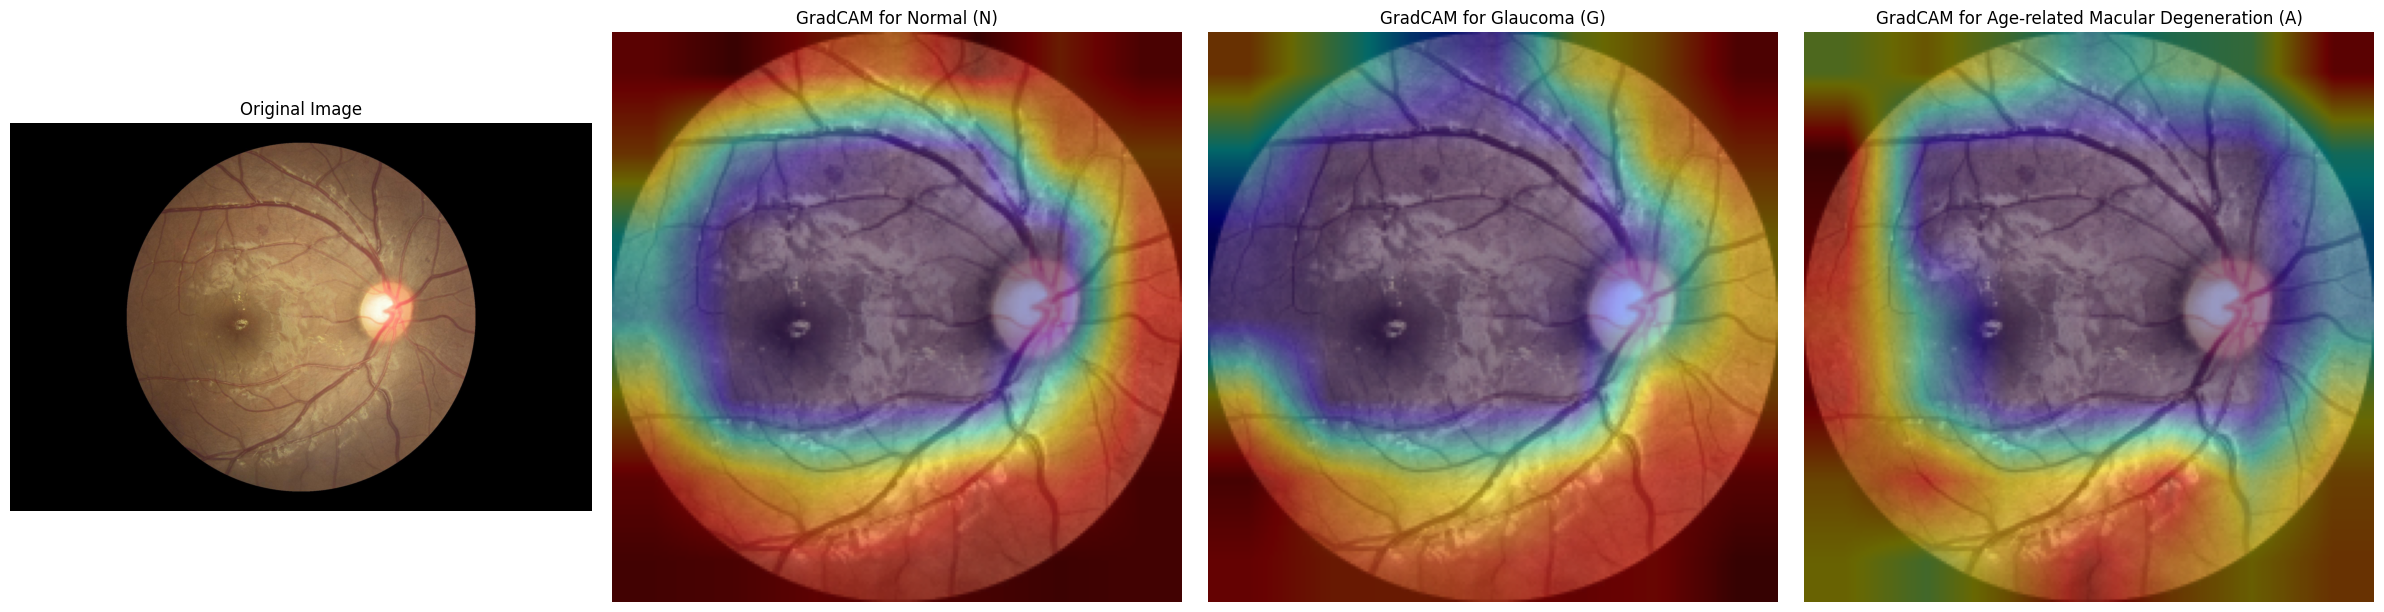

In [91]:
import matplotlib.pyplot as plt
import cv2
import os

# Define paths for the GradCAM images and the original image based on the new prediction
# The NEW_IMAGE_PATH and GRADCAM_OUTPUT_DIR are already defined in the previous cell

# Dynamically get the detected diseases from the prediction_result variable
detected_diseases_codes = [d['code'] for d in prediction_result['detected_diseases']]

# Prepare paths for the original image and GradCAMs for detected diseases
images_to_display = []

# Add the original image path
images_to_display.append({
    "path": NEW_IMAGE_PATH,
    "title": "Original Image",
    "type": "original"
})

# Add GradCAM paths for each detected disease
for disease_code in detected_diseases_codes:
    gradcam_path = os.path.join(GRADCAM_OUTPUT_DIR, f"967_right_{disease_code}_gradcam.png")
    images_to_display.append({
        "path": gradcam_path,
        "title": f"GradCAM for {prediction_result['detected_diseases'][detected_diseases_codes.index(disease_code)]['name']} ({disease_code})",
        "type": "gradcam"
    })

# Create a figure with dynamic number of subplots
num_subplots = len(images_to_display)
fig, axes = plt.subplots(1, num_subplots, figsize=(6 * num_subplots, 6))

# Handle case where there's only one subplot (axes might not be an array then)
if num_subplots == 1:
    axes = [axes]

for i, img_info in enumerate(images_to_display):
    image_path = img_info["path"]
    title = img_info["title"]
    ax = axes[i]

    if os.path.exists(image_path):
        img = cv2.imread(image_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(title)
            ax.axis("off")
        else:
            ax.set_title(f"{title} (Error loading)")
            ax.axis("off")
            print(f"Error loading image at: {image_path}")
    else:
        ax.set_title(f"{title} (Not found)")
        ax.axis("off")
        print(f"Image not found at: {image_path}")

plt.tight_layout()
plt.show()

## Project complete

Stage 1 (Modules 1-10, ODIR-5K only) and Stage 2 (Modules 11-15, ODIR + RFMiD combined,
cross-dataset evaluation, calibration, error analysis) are both implemented above.

Training cells in Modules 6, 12, and 13 use a **two-stage freeze -> unfreeze schedule**
with stronger weight decay and a lower fine-tuning learning rate to reduce overfitting on
the relatively small, imbalanced datasets. All training cells use `resume=True`, so if
Colab disconnects, simply re-run the same cell to continue from the last checkpoint.

In [89]:
print(summary_df)

  train_source test_source  accuracy  precision  recall_sensitivity  \
0         ODIR        ODIR  0.809961   0.398862            0.880762   
1         ODIR       RFMiD  0.703776   0.224679            0.493532   
2        RFMiD       RFMiD  0.832031   0.341745            0.654625   
3        RFMiD        ODIR  0.751563   0.294662            0.447771   
4     Combined        ODIR  0.825781   0.428786            0.813228   
5     Combined       RFMiD  0.841797   0.324509            0.584353   

   specificity        f1   roc_auc  subset_accuracy  
0     0.805332  0.528981  0.910118         0.220312  
1     0.688090  0.284220  0.726508         0.031250  
2     0.855370  0.384638  0.919385         0.291667  
3     0.793851  0.275516  0.670359         0.165625  
4     0.833430  0.529753  0.866324         0.235937  
5     0.829214  0.394943  0.883110         0.276042  


In [92]:
print(best_thresholds)

{'N': np.float64(0.35), 'D': np.float64(0.45), 'G': np.float64(0.9), 'C': np.float64(0.9), 'A': np.float64(0.85), 'H': np.float64(0.9), 'M': np.float64(0.9), 'O': np.float64(0.35)}


In [9]:
 !ls "{DRIVE_ROOT}/weights/odir_real_stage2/"

best_checkpoint.pt  last_checkpoint.pt
